<a href="https://colab.research.google.com/github/JordanPickles/airbnb_listings_analysis/blob/main/AirBnB_London_Listings_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**AirBnB London Listings Analysis**
Jet2 Data Science Interview Task

###**AirBnB revenue Model**
AirBnB's business revenue model works on a flat ~15.5% commission fee on the booking price which the host pays. Therefore the key drivers in AirBnB's revenue model are Nights Booked and Property Price. Increases in both of these factors result in greater revenues.

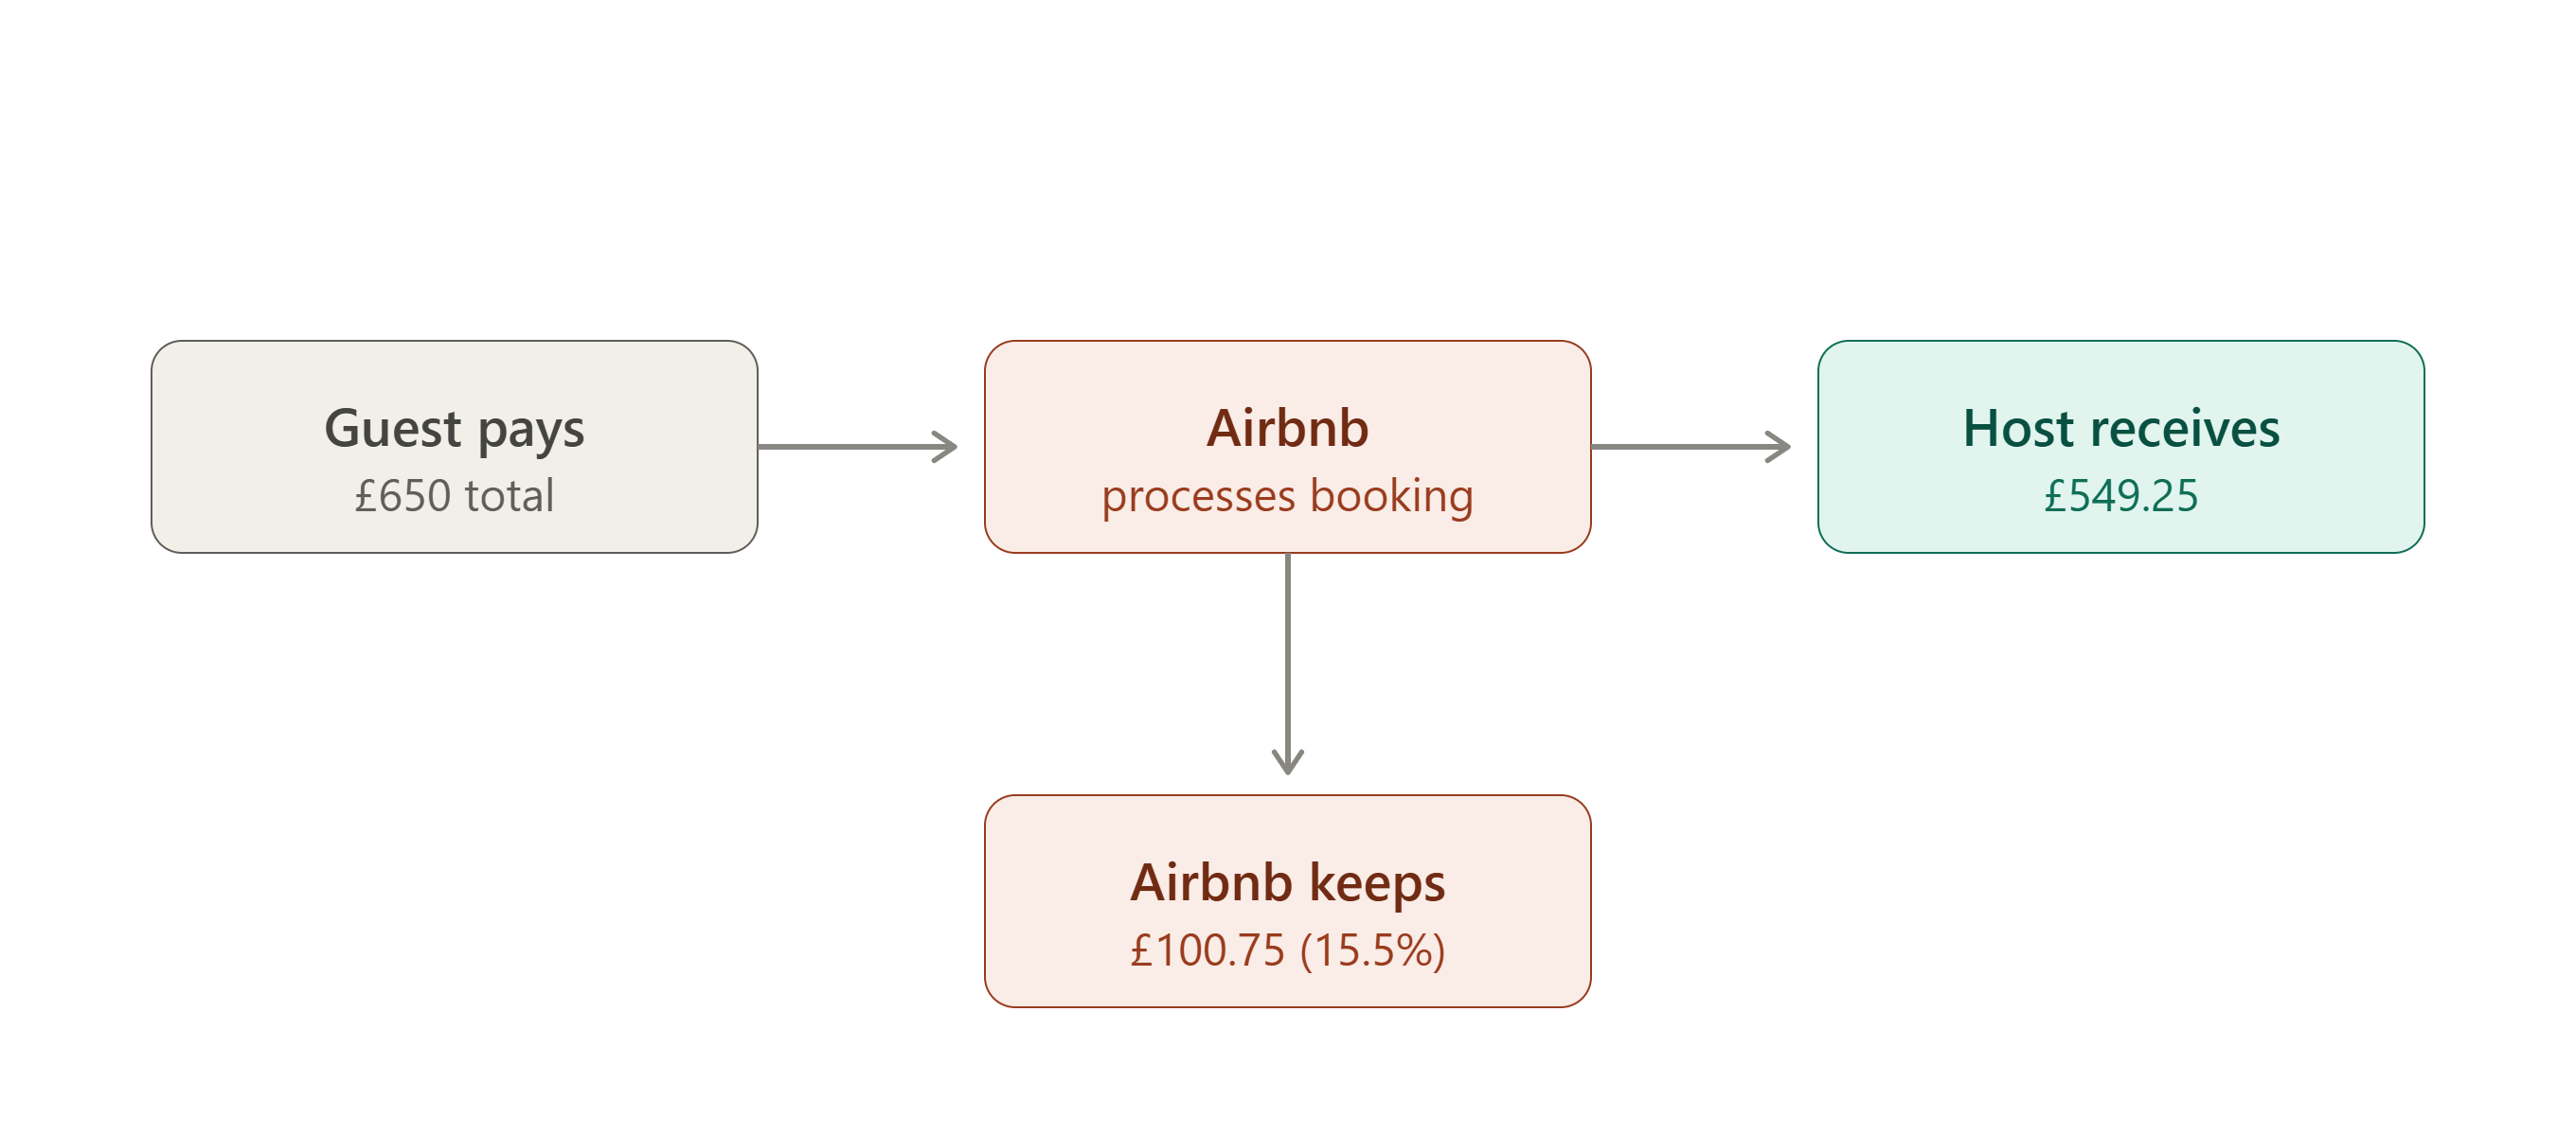

###**Analysis Overview**
Therefore the analysis on the Property Listings below focusses on the Property Price, highlights characteristics explaing variability in Price and identifies outliers within subgroups of properties which could be used by AirBnB to notify hosts that their property is mis-priced vs similar listings.

###**Findings Summary**
Price was found to be driven by the number of guests that can be accomodated (size), location and property type. Therefore outliers were detected within location and guests accommodated groups using the percentile ranks (bottom 10% as low pricing, top 90% as high priced).

### **Limitations**
Due to this dataset only including listings data and not booking or search & Conversion data, the outliers can only highlight potential mis-pricing. To understand if the property is actually mispriced, performance metrics would need to be included and this should be a pre-cursor to future analytics of the whole pictur. There is also the potential for this analysis to be the foundations of a full pricing elasticity solution.

In [341]:
# Importing the packages required for the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
pd.options.display.max_columns = None
plt.style.use('seaborn-v0_8-colorblind')

## **1. Data Preperation**
* Loading the data
* Investigating the dataset
  * Shape
  * Data types
* Change column data types
* Rename any columns that require renaming
* Wrangle data
  * Create data columns
  * drop columns not required


### 1.1 Loading the Data
* Downloads the file from my personal google drive and loads it into a pandas dataframe
* Prints the number of rows and columns in the data


In [342]:
gdown.download(id="1_xs-5Q5oODtu1c7Wvjdef7IwecORoqPQ", output="listings.csv", quiet=True)
df = pd.read_csv("listings.csv")
print(f"{df.shape[0]} rows & {df.shape[1]} columns")
df.head()

92638 rows & 35 columns


,id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_listings_count,neighbourhood_cleansed,property_type,property_type.1,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,11551,16.0,8.0,15.0,5.0,t,1.0,Lambeth,Entire rental unit,Entire rental unit,5,1.0,1 bath,1.0,3.0,"[""Carbon monoxide alarm"", ""Portable air condit...",234.50,1.0,1125.0,9,25,55,330,196,6,1,21/03/2010,05/06/2026,4.55,4.60,4.57,4.77,4.84,4.54,4.49
1,13913,16.0,7.0,15.0,5.0,f,2.0,Islington,Private room in rental unit,Private room in rental unit,1,1.0,1 shared bath,NaN,1.0,"[""Babysitter recommendations"", ""Coffee maker: ...",127.00,1.0,29.0,17,46,76,351,57,3,0,18/08/2010,31/03/2026,4.86,4.80,4.80,4.82,4.88,4.79,4.79
2,15400,16.0,6.0,15.0,5.0,f,1.0,Kensington and Chelsea,Entire rental unit,Entire rental unit,2,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Long term stays allowed"", ""C...",137.50,4.0,30.0,0,0,0,80,98,1,0,21/12/2009,30/03/2026,4.81,4.86,4.87,4.88,4.84,4.94,4.74
3,17402,16.0,5.0,15.0,5.0,t,3.0,Westminster,Entire rental unit,Entire rental unit,6,2.0,2 baths,3.0,3.0,"[""Drying rack for clothing"", ""Dishwasher"", ""Lo...",606.67,3.0,1125.0,10,37,67,71,57,1,0,21/03/2011,03/01/2026,4.77,4.84,4.73,4.73,4.73,4.89,4.62
4,513198,14.0,0.0,14.0,0.0,f,2.0,Lambeth,Private room in rental unit,Private room in rental unit,1,1.5,1.5 baths,1.0,1.0,"[""Oven"", ""City skyline view"", ""Toaster"", ""Priv...",68.30,10.0,210.0,14,26,30,182,43,2,0,11/08/2012,17/05/2026,4.42,4.67,3.63,4.79,4.74,4.72,4.42


### 1.2 Investigates the dataset columns
* Shows the column names, non-null counts and the datatype
* Interestingly shows for rows such as price that ~33% of rows are null


In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           92638 non-null  int64  
 1   hosts_time_as_user_years     92562 non-null  float64
 2   hosts_time_as_user_months    92562 non-null  float64
 3   hosts_time_as_host_years     92561 non-null  float64
 4   hosts_time_as_host_months    92561 non-null  float64
 5   host_is_superhost            92562 non-null  object 
 6   host_listings_count          92562 non-null  float64
 7   neighbourhood_cleansed       92638 non-null  object 
 8   property_type                92638 non-null  object 
 9   property_type.1              92638 non-null  object 
 10  accommodates                 92638 non-null  int64  
 11  bathrooms                    57762 non-null  float64
 12  bathrooms_text               92504 non-null  object 
 13  bedrooms        

In [344]:
df.describe()

,id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,9.263800e+04,92562.000000,92562.000000,92561.000000,92561.000000,92562.000000,92638.000000,57762.000000,68655.000000,60163.000000,62240.000000,92633.000000,9.263300e+04,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,70711.000000,70697.000000,70702.000000,70673.000000,70692.000000,70672.000000,70672.000000
mean,8.174866e+17,7.670037,5.454539,5.556023,5.400352,53.821774,3.387141,1.370174,1.767912,2.020993,271.469220,4.557631,2.148486e+05,8.636737,21.756633,36.255165,152.664447,24.148654,6.113971,0.545921,4.692911,4.732866,4.660909,4.797939,4.818871,4.741178,4.628688
std,6.546986e+17,4.120067,3.554372,3.979819,3.594906,444.149665,2.120560,0.735683,1.042125,1.451603,2190.599006,20.895917,2.123659e+07,10.180460,21.698970,33.559887,141.132463,55.082865,12.614952,1.269532,0.482131,0.465147,0.501149,0.413750,0.414242,0.394309,0.495310
min,1.155100e+04,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,1.000000,2.230000,1.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.540656e+07,4.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,100.000000,1.000000,9.900000e+01,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.600000,4.670000,4.540000,4.770000,4.800000,4.670000,4.500000
50%,9.688296e+17,9.000000,5.000000,6.000000,5.000000,2.000000,3.000000,1.000000,1.000000,2.000000,180.000000,2.000000,3.650000e+02,4.000000,17.000000,32.000000,127.000000,5.000000,1.000000,0.000000,4.830000,4.880000,4.810000,4.930000,4.960000,4.850000,4.750000
75%,1.425415e+18,11.000000,9.000000,9.000000,9.000000,10.000000,4.000000,1.500000,2.000000,3.000000,300.032500,3.000000,1.125000e+03,15.000000,41.000000,68.000000,301.000000,23.000000,6.000000,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.930000
max,1.710934e+18,17.000000,11.000000,15.000000,11.000000,5978.000000,16.000000,30.000000,30.000000,50.000000,527524.000000,1125.000000,2.147484e+09,30.000000,60.000000,90.000000,365.000000,1959.000000,499.000000,43.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### 1.3 Sets Column Data Types

In [345]:
df_clean = df.copy()
column_dtypes = {
    'id':str,
    'hosts_time_as_user_years':float,
    'hosts_time_as_user_months':float,
    'hosts_time_as_host_years':float,
    'hosts_time_as_host_months':float,
    'host_is_superhost':bool,
    'host_listings_count':int,
    'neighbourhood_cleansed':str,
    'property_type':str,
    'accommodates':int,
    'bathrooms':float,
    'bedrooms':float,
    'beds':float,
    'price':float,
    'minimum_nights':int,
    'maximum_nights':int,
    'availability_30':int,
    'availability_60':int,
    'availability_90':int,
    'availability_365':int,
    'number_of_reviews':float,
    'number_of_reviews_ltm':float,
    'number_of_reviews_l30d':float,
    'review_scores_rating':float,
    'review_scores_accuracy':float,
    'review_scores_cleanliness':float,
    'review_scores_checkin':float,
    'review_scores_communication':float,
    'review_scores_location':float,
    'review_scores_value':float
}
for column, data_type in column_dtypes.items():
  df_clean[column] = df_clean[column].astype(data_type, errors='ignore')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           92638 non-null  object 
 1   hosts_time_as_user_years     92562 non-null  float64
 2   hosts_time_as_user_months    92562 non-null  float64
 3   hosts_time_as_host_years     92561 non-null  float64
 4   hosts_time_as_host_months    92561 non-null  float64
 5   host_is_superhost            92638 non-null  bool   
 6   host_listings_count          92562 non-null  float64
 7   neighbourhood_cleansed       92638 non-null  object 
 8   property_type                92638 non-null  object 
 9   property_type.1              92638 non-null  object 
 10  accommodates                 92638 non-null  int64  
 11  bathrooms                    57762 non-null  float64
 12  bathrooms_text               92504 non-null  object 
 13  bedrooms        

### 1.4 Rename column

In [346]:
df_clean = df_clean.rename(columns={'neighbourhood_cleansed':'neighbourhood'})
df_clean.columns


Index(['id', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_is_superhost', 'host_listings_count', 'neighbourhood',
       'property_type', 'property_type.1', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value'],
      dtype='object')

### 1.5 Column Manipulation
* Combining User / Host Year & Months
* Drops the raw columns once new columns are created
* Creates a new bathroom column taking the bathroom column number, if it is null then it strips the first part of the bathroom text field and converts it to a number to ensure the bathroom column is as clean as possible
* Grouping of Property Names

In [347]:
df_clean['hosts_time_as_user'] = df_clean['hosts_time_as_user_years'] + (df_clean['hosts_time_as_user_months']/12) # Normalises the month to a decimal to make it more analytically friendly
df_clean['hosts_time_as_host'] = df_clean['hosts_time_as_host_years'] + (df_clean['hosts_time_as_host_months']/12)
df_clean = df_clean.drop(['hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months'], axis=1).copy()
df_clean.head()

,id,host_is_superhost,host_listings_count,neighbourhood,property_type,property_type.1,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,hosts_time_as_user,hosts_time_as_host
0,11551,True,1.0,Lambeth,Entire rental unit,Entire rental unit,5,1.0,1 bath,1.0,3.0,"[""Carbon monoxide alarm"", ""Portable air condit...",234.50,1.0,1125.0,9,25,55,330,196.0,6.0,1.0,21/03/2010,05/06/2026,4.55,4.60,4.57,4.77,4.84,4.54,4.49,16.666667,15.416667
1,13913,True,2.0,Islington,Private room in rental unit,Private room in rental unit,1,1.0,1 shared bath,NaN,1.0,"[""Babysitter recommendations"", ""Coffee maker: ...",127.00,1.0,29.0,17,46,76,351,57.0,3.0,0.0,18/08/2010,31/03/2026,4.86,4.80,4.80,4.82,4.88,4.79,4.79,16.583333,15.416667
2,15400,True,1.0,Kensington and Chelsea,Entire rental unit,Entire rental unit,2,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Long term stays allowed"", ""C...",137.50,4.0,30.0,0,0,0,80,98.0,1.0,0.0,21/12/2009,30/03/2026,4.81,4.86,4.87,4.88,4.84,4.94,4.74,16.500000,15.416667
3,17402,True,3.0,Westminster,Entire rental unit,Entire rental unit,6,2.0,2 baths,3.0,3.0,"[""Drying rack for clothing"", ""Dishwasher"", ""Lo...",606.67,3.0,1125.0,10,37,67,71,57.0,1.0,0.0,21/03/2011,03/01/2026,4.77,4.84,4.73,4.73,4.73,4.89,4.62,16.416667,15.416667
4,513198,True,2.0,Lambeth,Private room in rental unit,Private room in rental unit,1,1.5,1.5 baths,1.0,1.0,"[""Oven"", ""City skyline view"", ""Toaster"", ""Priv...",68.30,10.0,210.0,14,26,30,182,43.0,2.0,0.0,11/08/2012,17/05/2026,4.42,4.67,3.63,4.79,4.74,4.72,4.42,14.000000,14.000000


In [348]:
print(f"Before manipulation there were {df_clean['bathrooms'].isna().sum()} null columns")
num = df_clean['bathrooms_text'].str.split().str[0]      # take the first word as the number typically at the front of the text: "1.5 shared baths" = "1.5"
num = pd.to_numeric(num, errors='coerce')          # "1.5" = 1.5, "Half-bath" = NaN
df_clean['bathrooms_clean'] = df_clean['bathrooms'].fillna(num)
df_clean = df_clean.drop(['bathrooms', 'bathrooms_text'], axis=1).copy()

print(f"After manipulation there were {df_clean['bathrooms_clean'].isna().sum()} null columns")
df_clean = df_clean.rename(columns={'bathrooms_clean':'bathroom'})

Before manipulation there were 34876 null columns
After manipulation there were 353 null columns


In [349]:

# creates a df of rows where beds in na
df_no_bedroom = df_clean[df_clean['bedrooms'].isna() & df_clean['beds'].isna()]
print(f"{df_no_bedroom.shape[0]} rows have null bedrooms and beds")

# counts the number of nulls by id
#print(df_no_bedroom.groupby('property_type').count()['id'])

# any property termed room with accommodates less than 3 and has a null value for bed will be imputed with bed = 1 and bedroom = 1
df_no_bedroom_rooms_only = df_no_bedroom[df_no_bedroom['property_type'].str.contains('room', case=False, na=False)]
df_no_bedroom_rooms_only.groupby('accommodates').count()['id']
df_no_bedroom_rooms_only_imputation = df_no_bedroom_rooms_only[df_no_bedroom_rooms_only['accommodates'] <3]


# creates a df with each index true or false
impute_rows = (
    df_clean['property_type'].str.contains('room', case=False, na=False)
    & df_clean['beds'].isna()
    & df_clean['bedrooms'].isna()
    & (df_clean['accommodates'] < 3)
)

df_clean['beds_imputed'] = impute_rows
df_clean['bedrooms_imputed'] = impute_rows

df_clean.loc[impute_rows, 'beds'] = 1
df_clean.loc[impute_rows, 'bedrooms'] = 1

df_no_bedroom_post = df_clean[df_clean['bedrooms'].isna() & df_clean['beds'].isna()]
print(f"{impute_rows.sum()} rows imputated")
print(f"{df_no_bedroom_post.shape[0]} rows have null bedrooms and beds")


10714 rows have null bedrooms and beds
9342 rows imputated
1372 rows have null bedrooms and beds


In [350]:
# Grouping property names from lots of variations of a name to a more useful grouping
df_clean['property_type'].unique()

array(['Entire rental unit', 'Private room in rental unit', 'Entire home',
       'Private room in condo', 'Private room in townhouse',
       'Private room in home', 'Entire condo', 'Private room in loft',
       'Entire townhouse', 'Entire loft', 'Room in serviced apartment',
       'Private room in bed and breakfast', 'Private room in bungalow',
       'Room in aparthotel', 'Shared room in loft',
       'Entire serviced apartment', 'Entire cabin', 'Entire guest suite',
       'Houseboat', 'Private room in guesthouse',
       'Private room in guest suite',
       'Private room in serviced apartment', 'Boat',
       'Private room in villa', 'Shared room in condo', 'Entire cottage',
       'Tiny home', 'Private room in cottage', 'Room in hotel',
       'Private room in tiny home', 'Entire guesthouse', 'Private room',
       'Room in boutique hotel', 'Shared room in home', 'Entire place',
       'Room in bed and breakfast', 'Entire bungalow', 'Camper/RV',
       'Private room in hut', '

In [351]:
def group_property_type(property_type) -> str:
#Groups property name into a wider grouping of property type Args: Property Type: str Output: Property Group: Str
  property_type_cleaned = str(property_type).lower()
  if property_type_cleaned.startswith('entire') or property_type_cleaned in ('entire place', 'entire home/aproperty_type'):
      return 'Entire Property'
  elif 'private room' in property_type_cleaned or property_type_cleaned == 'private room':
      return 'Private room'
  elif 'shared room' in property_type_cleaned:
      return 'Shared room'
  elif property_type_cleaned.startswith('room in'):
      return 'Hotel/BnB'
  return 'Other'

df_clean['listing_type'] = df_clean['property_type'].map(group_property_type)
df_clean['listing_type'].value_counts(dropna=False)

,count
listing_type,
Entire Property,61105
Private room,29513
Hotel/BnB,1580
Other,237
Shared room,203


### 1.6 Checking Duplicates
* Checks for duplicates across all columns
* Importantly the id column which is the primary key is 0 and therefore no duplicates need removing as each row is a unique listing

In [352]:
df_clean.isna().sum()

,0
id,0
host_is_superhost,0
host_listings_count,76
neighbourhood,0
property_type,0
property_type.1,0
accommodates,0
bedrooms,14641
beds,23133
amenities,0


### 1.7 Filtering Table to Return Only live lisitngs
Inclusion Criteria to ensure valid listing that is being booked & not sat idle:
* Listing has a price
* Listing has > 0 reviews in the last 12 months
* Availability in the next 365 days > 0


In [353]:
df_clean.isna().sum()

,0
id,0
host_is_superhost,0
host_listings_count,76
neighbourhood,0
property_type,0
property_type.1,0
accommodates,0
bedrooms,14641
beds,23133
amenities,0


In [354]:
print(f"The column price has {df_clean['price'].isna().sum()} nulls")
# As the price column is the primary column to be included in this analysis, all rows with price null will be dropped
df_clean = df_clean.dropna(subset=['price']).copy()
print(f"The column price has {df_clean['price'].isna().sum()} nulls now")

The column price has 30398 nulls
The column price has 0 nulls now


In [355]:
print(f"{df_clean[df_clean['number_of_reviews_ltm'] < 1].shape[0]} rows have less than 1 review in the last 12 months")
df_clean = df_clean[df_clean['number_of_reviews_ltm'] > 0].copy()
print(f"{df_clean.shape[0]} rows remain")


21240 rows have less than 1 review in the last 12 months
41000 rows remain


In [356]:
print(f"{df_clean[df_clean['availability_365'] < 1].shape[0]} rows have less than 1 review in the last 12 months")
df_clean = df_clean[df_clean['availability_365'] > 0].copy()
print(f"{df_clean.shape[0]} rows remain")

3 rows have less than 1 review in the last 12 months
40997 rows remain


In [357]:
df_clean.isna().sum()

,0
id,0
host_is_superhost,0
host_listings_count,57
neighbourhood,0
property_type,0
property_type.1,0
accommodates,0
bedrooms,8637
beds,2422
amenities,0


### 1.8 Dropping Columns
* Columns not to be used within this analysis are dropped



In [358]:
df_clean = df_clean.drop(columns=['property_type.1', # duplicate column
                      'first_review', # integer columns for reviews last 30 days and last 12 months are more useful here
                      'last_review',
                      'amenities' # no text analysis to be conducted in this analysis and amenities provides a list of text
                                  ],
                      axis=1
                      ).copy()

### 1.9 Outlier Detection

Data Distribution plot for all continuous and ordinal data

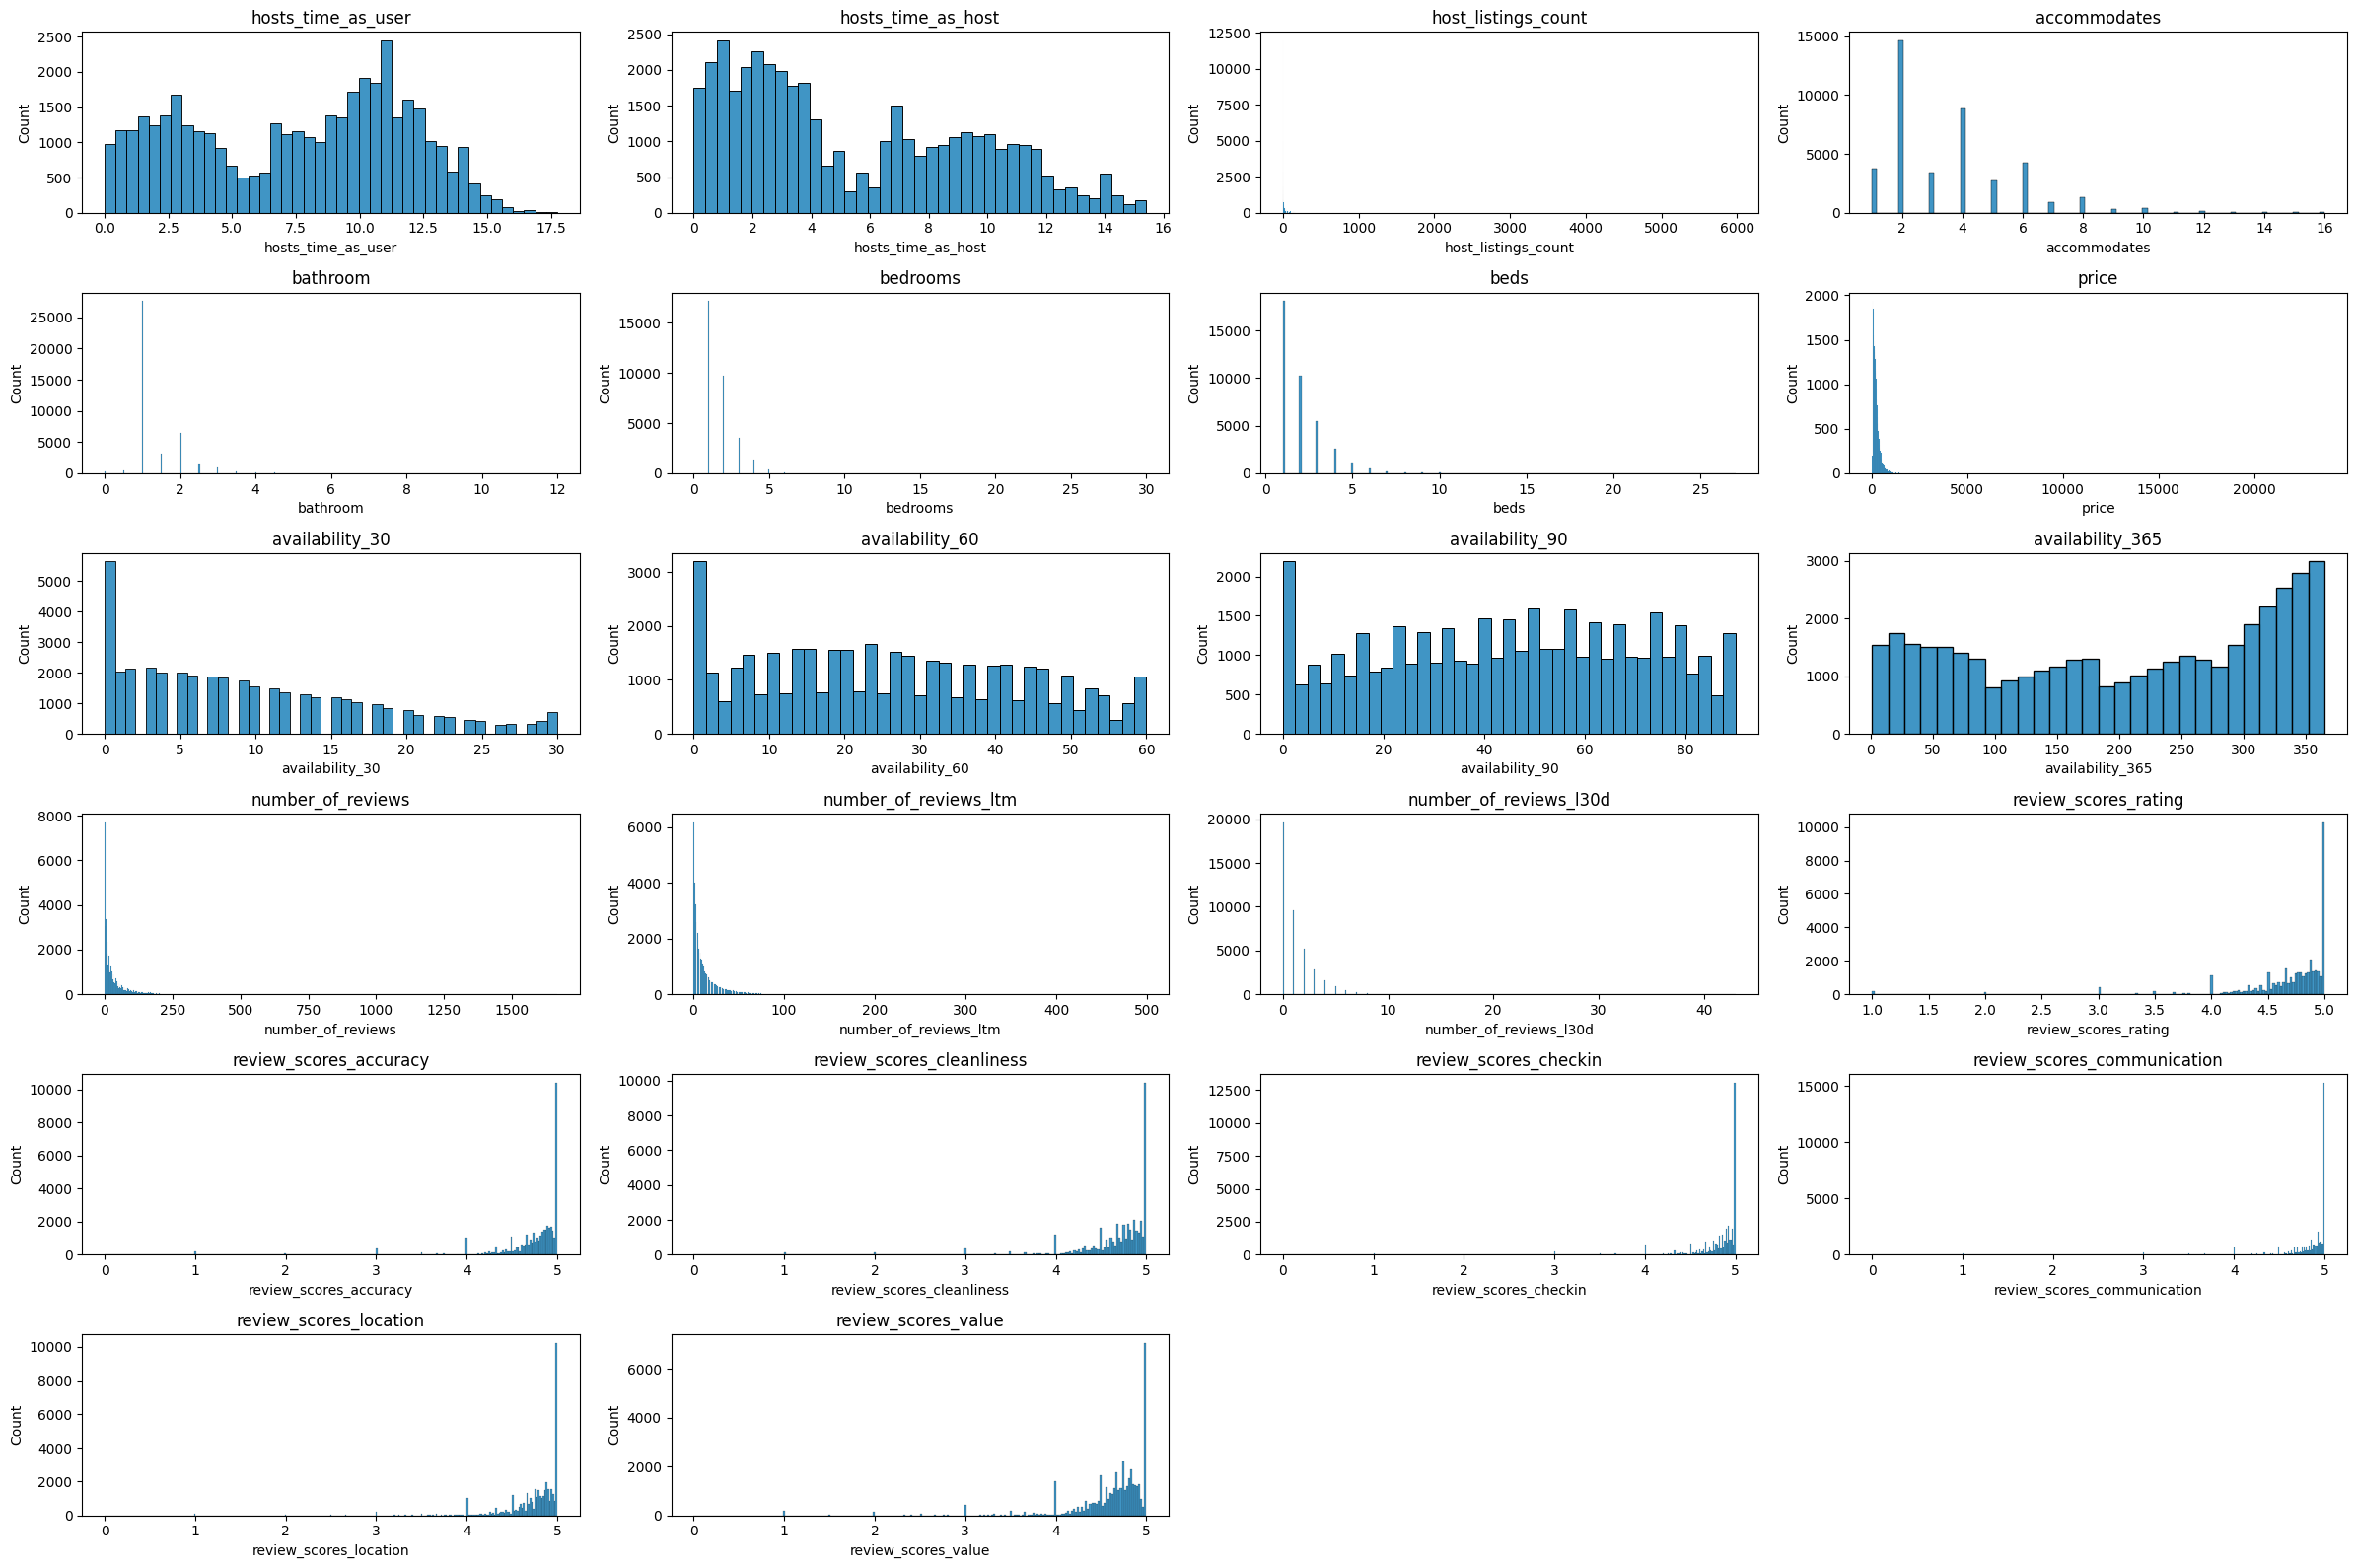

In [359]:
fig, axes = plt.subplots(6,4, figsize=(24,16))
axes = axes.flatten()
variables = [
            'hosts_time_as_user',
             'hosts_time_as_host',
             'host_listings_count',
             'accommodates',
             'bathroom',
             'bedrooms',
             'beds',
             'price',
             'availability_30',
             'availability_60',
             'availability_90',
             'availability_365',
             'number_of_reviews',
             'number_of_reviews_ltm',
             'number_of_reviews_l30d',
             'review_scores_rating',
             'review_scores_accuracy',
             'review_scores_cleanliness',
             'review_scores_checkin',
             'review_scores_communication',
             'review_scores_location',
             'review_scores_value'
             ]

for i, metric in enumerate(variables):
  ax=axes[i]
  sns.histplot(df_clean, x=metric, ax=ax)
  ax.set_title(metric)

for ax in axes[len(variables):]: # hides axes for indexes > than the number of variables included. Tidies up the viz
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Investigating outliers in Price

<Axes: xlabel='price', ylabel='Count'>

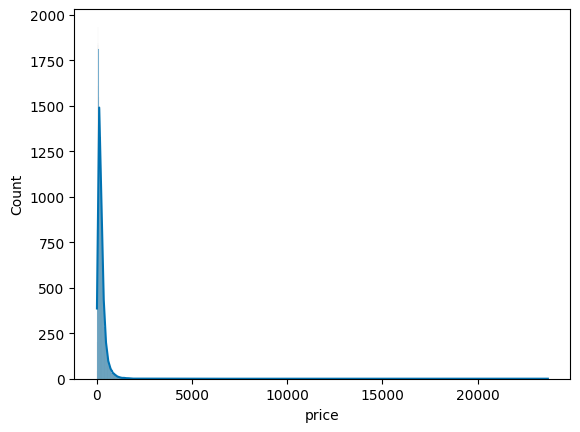

In [360]:
sns.histplot(df_clean, x='price', kde=True)


<Axes: xlabel='price'>

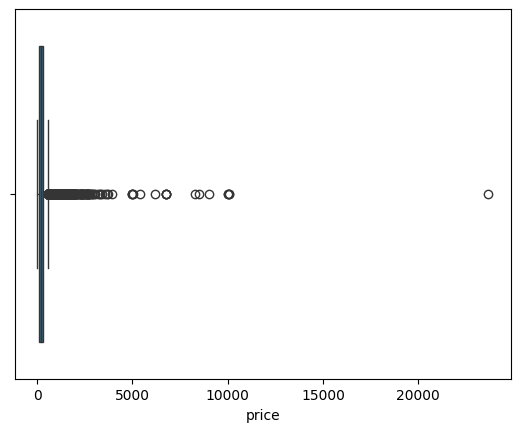

In [361]:
sns.boxplot(df_clean, x ='price')

Calculating Outliers using IQR
* Used IQR here as normal distribution not required

In [362]:
q1 = df_clean['price'].quantile(0.25)
q3 = df_clean['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
df_outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]
df_outliers.head()

,id,host_is_superhost,host_listings_count,neighbourhood,property_type,accommodates,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,hosts_time_as_user,hosts_time_as_host,bathroom,beds_imputed,bedrooms_imputed,listing_type
3,17402,True,3.0,Westminster,Entire rental unit,6,3.0,3.0,606.67,3.0,1125.0,10,37,67,71,57.0,1.0,0.0,4.77,4.84,4.73,4.73,4.73,4.89,4.62,16.416667,15.416667,2.0,False,False,Entire Property
44,523635,True,1.0,Islington,Entire townhouse,6,3.0,3.0,588.00,3.0,1125.0,1,1,1,23,52.0,5.0,0.0,5.00,4.98,5.00,4.96,5.00,4.98,4.85,14.000000,14.000000,2.0,False,False,Entire Property
89,536751,True,6.0,Westminster,Entire condo,4,2.0,2.0,805.00,2.0,365.0,15,37,65,327,171.0,24.0,2.0,4.91,4.89,4.88,4.91,4.95,4.94,4.75,14.916667,14.083333,3.0,False,False,Entire Property
210,566364,True,3.0,Islington,Entire rental unit,7,3.0,4.0,745.00,1.0,700.0,6,19,38,185,37.0,8.0,0.0,4.73,4.68,4.81,4.81,4.78,4.97,4.57,14.250000,13.916667,2.0,False,False,Entire Property
353,604687,True,1.0,Westminster,Entire rental unit,5,2.0,3.0,760.00,3.0,365.0,17,47,77,343,65.0,5.0,0.0,4.91,4.97,4.95,4.95,4.98,4.86,4.91,13.916667,13.916667,2.0,False,False,Entire Property


Investigating Outliers with High Prices

In [363]:
df_outliers[['neighbourhood', 'property_type', 'accommodates', 'bedrooms', 'price', 'minimum_nights']].sort_values(by='price', ascending=False)

,neighbourhood,property_type,accommodates,bedrooms,price,minimum_nights
56041,Lambeth,Private room in rental unit,3,NaN,23686.00,2.0
65134,Haringey,Entire rental unit,6,2.0,10070.50,2.0
57175,Westminster,Entire rental unit,2,1.0,10053.50,2.0
25762,Tower Hamlets,Entire serviced apartment,2,1.0,10000.00,1.0
47478,Bromley,Entire rental unit,4,2.0,10000.00,4.0
...,...,...,...,...,...,...
52502,Westminster,Entire home,5,3.0,584.00,1.0
17184,Lambeth,Entire townhouse,6,4.0,584.00,2.0
10671,Tower Hamlets,Entire loft,9,3.0,584.00,2.0
32640,Westminster,Entire rental unit,4,2.0,583.67,2.0


The Outliers table here shows that some are likely feasible, such as properties which accommodates large numbers.
News articles suggest that entire properties above 10k per night are feasible in central london, suggesting that these outliers are valid and are to be kept.

However, some listings, such as the Lambeth Private room in rental unit at £23,686 per night for 3 people does not seem feasible and therefore the below exclusion criteria will be implemented:
* Property type includes 'private room' & price per night > 1500


In [364]:
private_room = df_clean['property_type'].str.contains('private room', case=False, na=False)
private_room_expensive = private_room & (df_clean['price'] > 1500)
df_clean[private_room_expensive][['property_type', 'accommodates', 'neighbourhood', 'price']].sort_values('price', ascending=False)



,property_type,accommodates,neighbourhood,price
56041,Private room in rental unit,3,Lambeth,23686.0
56388,Private room in rental unit,2,Southwark,8500.0
27861,Private room in condo,1,Southwark,5393.2
40000,Private room in rental unit,3,Lambeth,5001.0
63900,Private room in rental unit,3,Lambeth,5000.0
73997,Private room in rental unit,3,Southwark,3553.0


In [365]:
df_clean = df_clean[~private_room_expensive].copy()

Investigating the bottom end of the outliers
* There are no outliers below the bottom band
* Expected due to the distribution being so concentrated at lower prices
* For completeness, the lower end of pricing per night will be checked

In [366]:
df_outliers[['neighbourhood', 'property_type', 'accommodates', 'bedrooms', 'price', 'minimum_nights']].sort_values(by='price', ascending=True)

,neighbourhood,property_type,accommodates,bedrooms,price,minimum_nights
32640,Westminster,Entire rental unit,4,2.0,583.67,2.0
75720,Westminster,Entire home,7,3.0,583.67,1.0
10671,Tower Hamlets,Entire loft,9,3.0,584.00,2.0
87875,Tower Hamlets,Entire condo,8,3.0,584.00,1.0
52502,Westminster,Entire home,5,3.0,584.00,1.0
...,...,...,...,...,...,...
25762,Tower Hamlets,Entire serviced apartment,2,1.0,10000.00,1.0
47478,Bromley,Entire rental unit,4,2.0,10000.00,4.0
57175,Westminster,Entire rental unit,2,1.0,10053.50,2.0
65134,Haringey,Entire rental unit,6,2.0,10070.50,2.0


In [367]:
df_clean[['neighbourhood', 'property_type', 'accommodates', 'bedrooms', 'price', 'minimum_nights']].sort_values(by='price', ascending=True).head(20)

,neighbourhood,property_type,accommodates,bedrooms,price,minimum_nights
42494,Southwark,Private room in rental unit,2,1.0,10.49,2.0
46187,Tower Hamlets,Private room in condo,1,1.0,11.06,120.0
59698,Redbridge,Entire rental unit,2,1.0,11.42,2.0
42357,Hounslow,Private room in home,1,NaN,11.96,1.0
64043,Westminster,Shared room in hotel,1,NaN,12.00,1.0
62265,Hillingdon,Private room in rental unit,2,1.0,12.61,90.0
68165,Redbridge,Entire rental unit,2,1.0,13.06,2.0
28742,Southwark,Private room in rental unit,2,1.0,13.49,2.0
63577,Lewisham,Private room in home,1,1.0,14.70,60.0
71273,Croydon,Entire rental unit,2,NaN,14.70,2.0


The table above shows that eventhough they aren't outliers based on IQR, there are some listings which we would not want to include in our data, such as:
* Minimum nights such as 90 are typically long lets or sublets and command a lower price per night. These are not typical airbnb listings but more rentals
* Shared room property type and accomodates > 3 as price is per person and not for all the accommodated
* Entire properties with a price < £20 per night

As a result, the following exclusion criteria will be followed
* Minimum Nights >= 28
* entire properties with price per night < £20
* Property type includes 'room' and accommodates > 3

In [368]:
# Flagging the properties with minimum_nights >28 as they are going into the realms of short term rentals
long_lets = df_clean['minimum_nights'] >= 28
# Flagging properties with property name entire but extremely cheap which isn't feasible
impossible_entire_property = df_clean['property_type'].str.contains('entire', case=False, na=False) & (df_clean['price'] < 20)
#Flagging listings which are listed as just a room but sleeps more than 4 which is not feasible
room_mismatch = df_clean['property_type'].str.contains('room', case=False, na=False) & (df_clean['accommodates'] > 3)

In [369]:
rows_to_drop = long_lets | impossible_entire_property | room_mismatch
df_clean = df_clean[~rows_to_drop].copy()

In [370]:
df_clean.shape

(39676, 31)

# **2. Analysing Drivers of Price**
* Univariate Analysis
* Multivariate Analysis
  * Understanding which factors are correlated to price
* Bucketing Listings on Drivers of price
* Highlighting listings that are outliers based on price within their buckets

### **2.1 Univariate Analysis
* Analyses data distribtuions of numerical fields
* Analyses value counts of categorical fields of interest (location & Property Types)

<Axes: xlabel='price', ylabel='Count'>

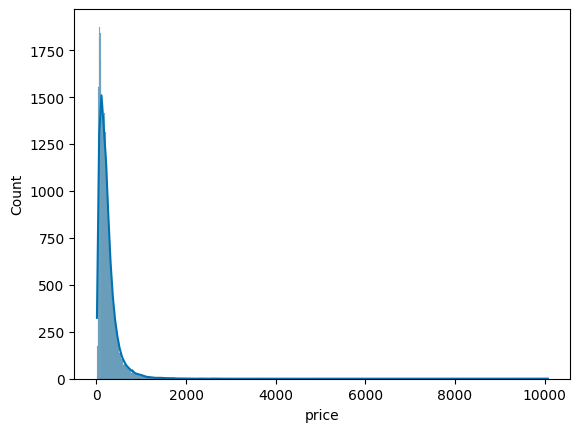

In [371]:
sns.histplot(df_clean, x='price', kde=True)

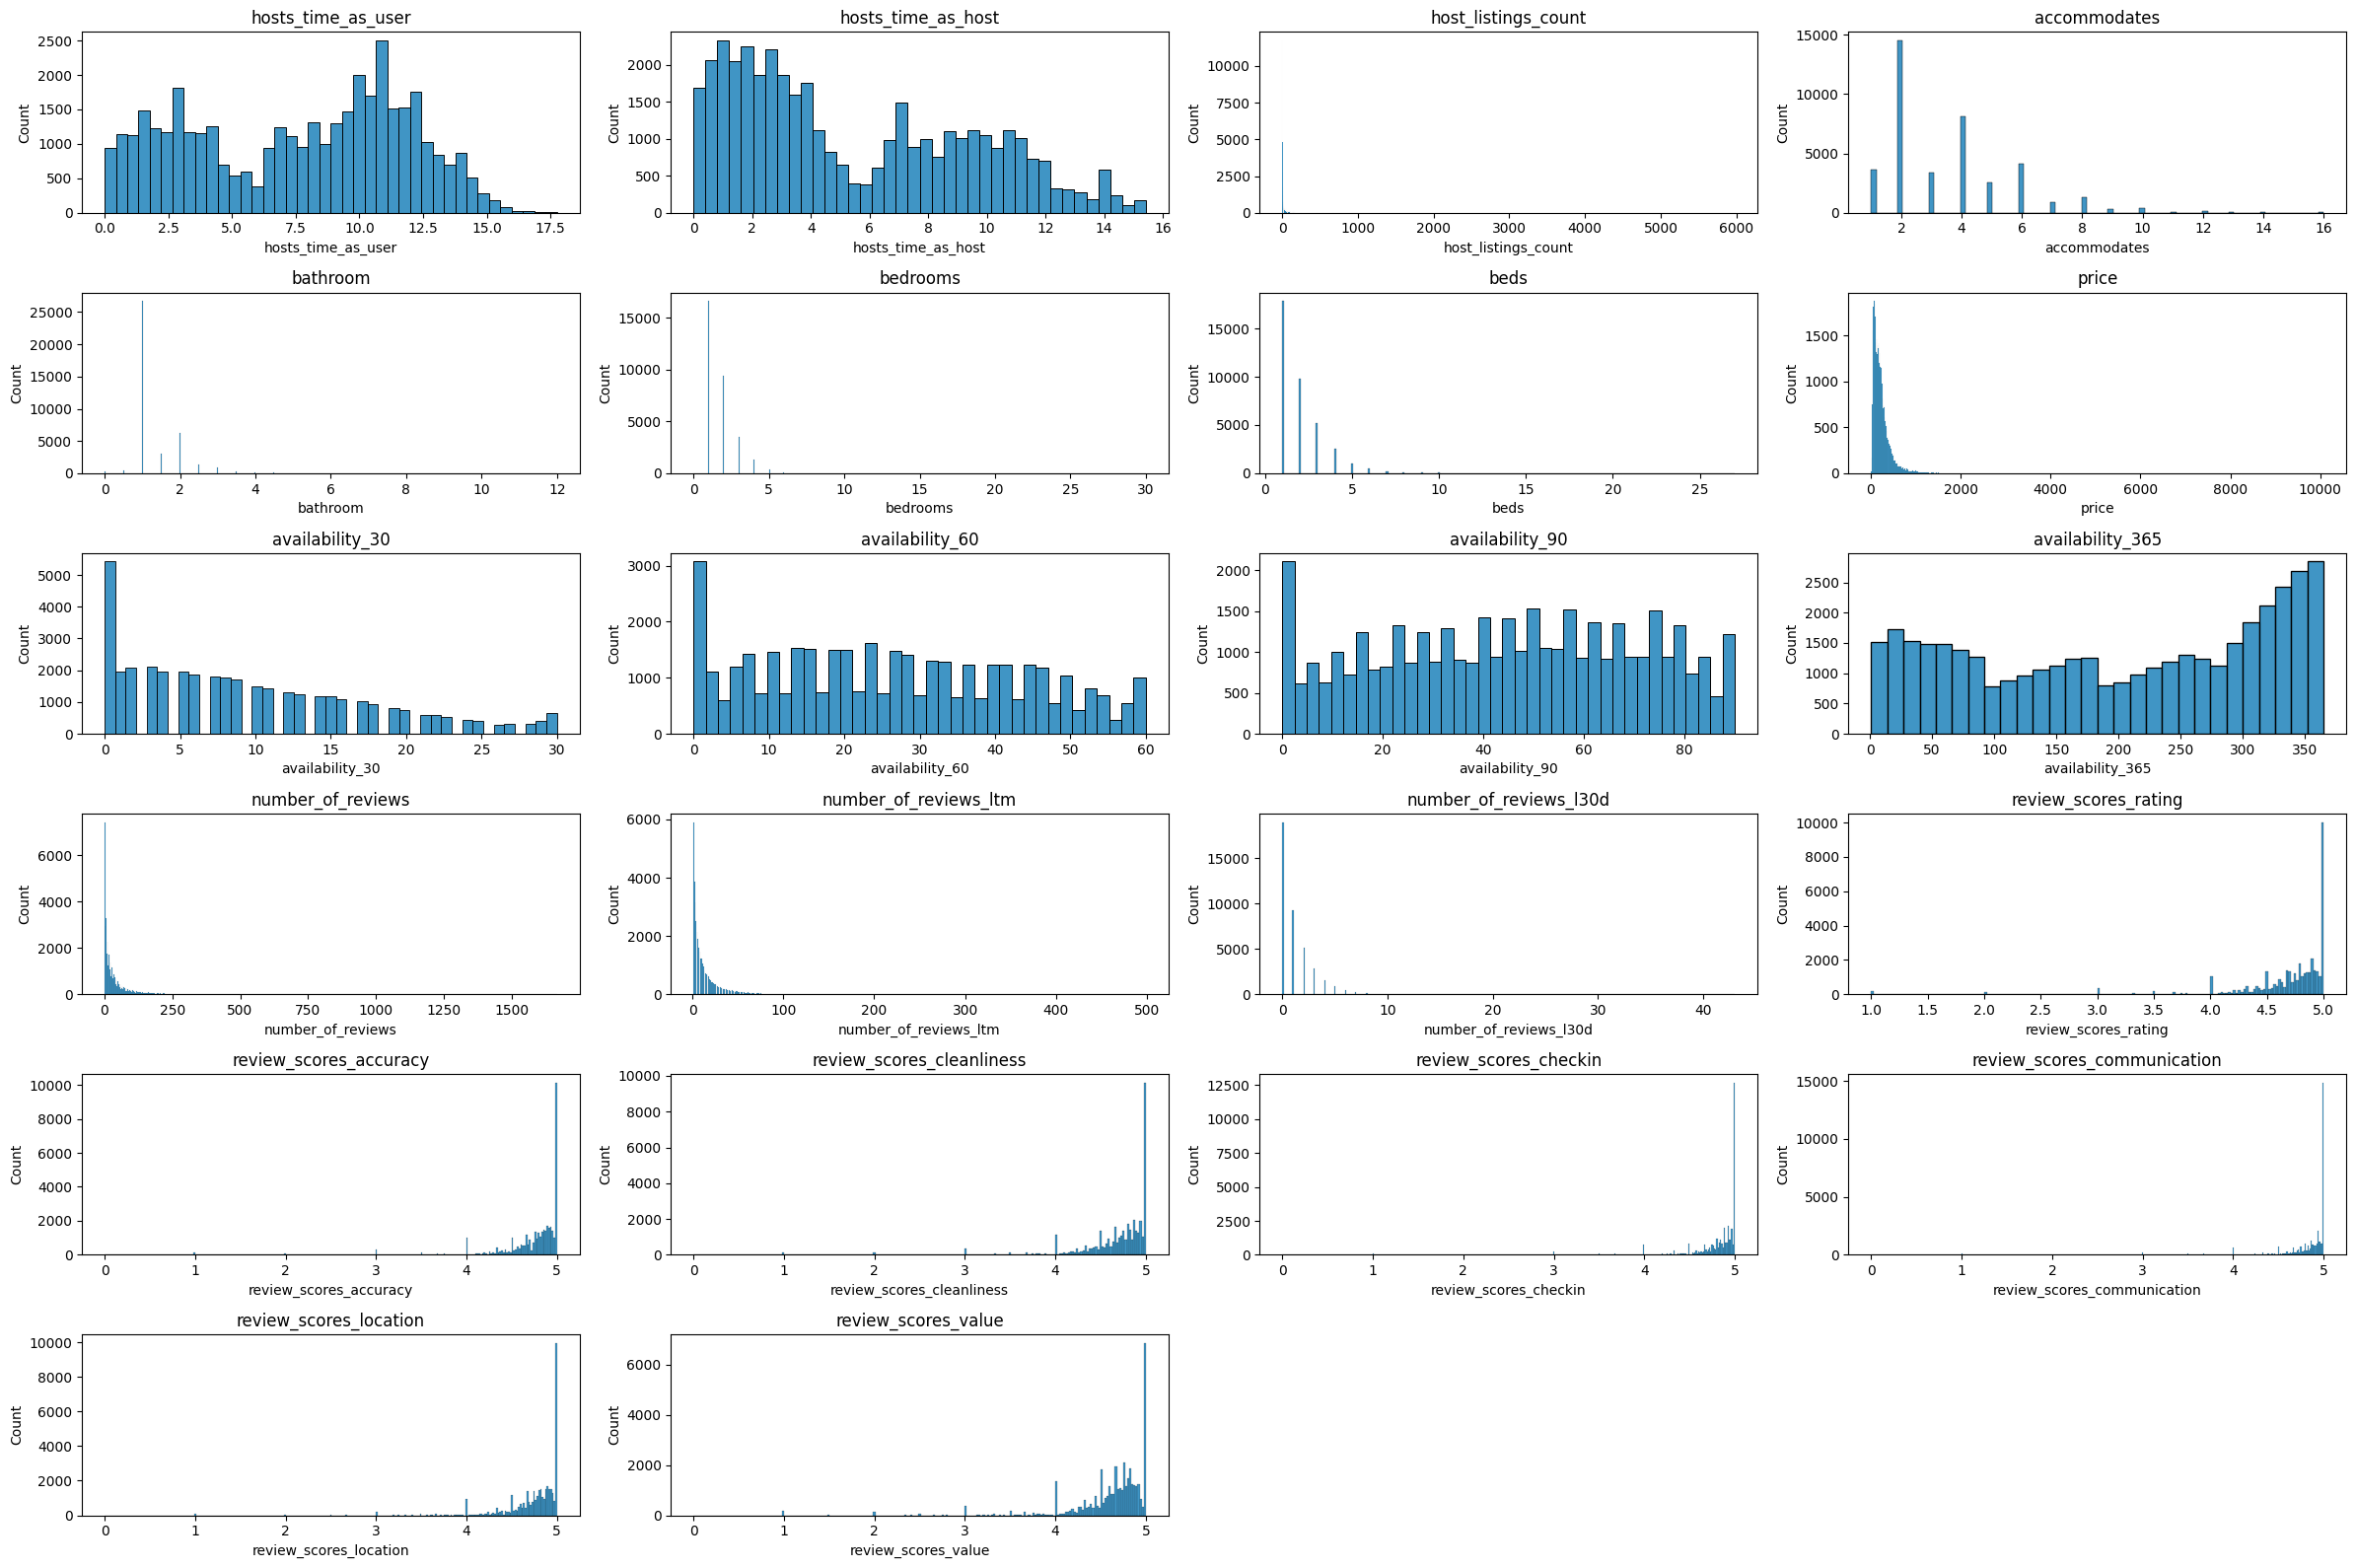

In [319]:
fig, axes = plt.subplots(6,4, figsize=(24,16))
axes = axes.flatten()
variables = [
            'hosts_time_as_user',
             'hosts_time_as_host',
             'host_listings_count',
             'accommodates',
             'bathroom',
             'bedrooms',
             'beds',
             'price',
             'availability_30',
             'availability_60',
             'availability_90',
             'availability_365',
             'number_of_reviews',
             'number_of_reviews_ltm',
             'number_of_reviews_l30d',
             'review_scores_rating',
             'review_scores_accuracy',
             'review_scores_cleanliness',
             'review_scores_checkin',
             'review_scores_communication',
             'review_scores_location',
             'review_scores_value'
             ]

for i, metric in enumerate(variables):
  ax=axes[i]
  sns.histplot(df_clean, x=metric, ax=ax)
  ax.set_title(metric)

for ax in axes[len(variables):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The above histogram plots shows that all accomodation information data is right skewed with the majority of listings having smaller number of people, bedrooms etc. Availability is heavily populated around 0, however we have filtered >0 so these are showing a very low number of nights available. Suggesting low availability or idle bookings. The availability 365 is bimodal with the greatest peak coming between 300 and 365

The review numbers are heavily right skewed with the majorirt of listings having a low number of reviews and reduces their reliability. However, we do not have booking numbers to understand the % of bookings which left reviews.

The actual review scores are very heavily left skewed with almost all variability coming between 4 and 5 with most reviews populating at 5, the ceiling for this.

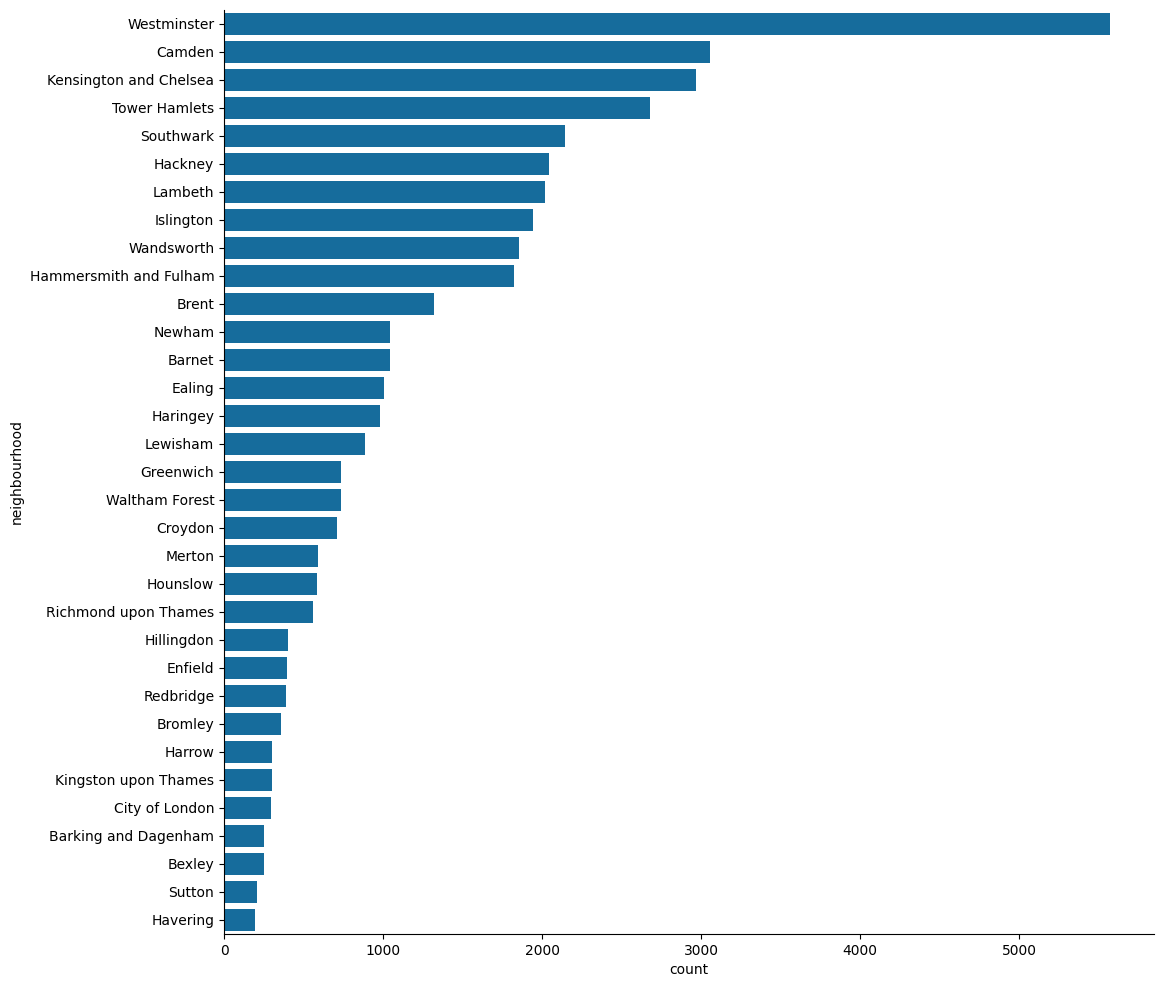

In [320]:
neighbourhood_order = df_clean['neighbourhood'].value_counts().index
plt.figure(figsize=(12,12))
sns.countplot(data=df_clean, y='neighbourhood', order=neighbourhood_order)
sns.despine(right=True, top=True)

The above visual shows that a Westminster has a much greater number of properties listed than other areas within london. This would need to be taken into account should any classification models be created

<Axes: xlabel='count', ylabel='listing_type'>

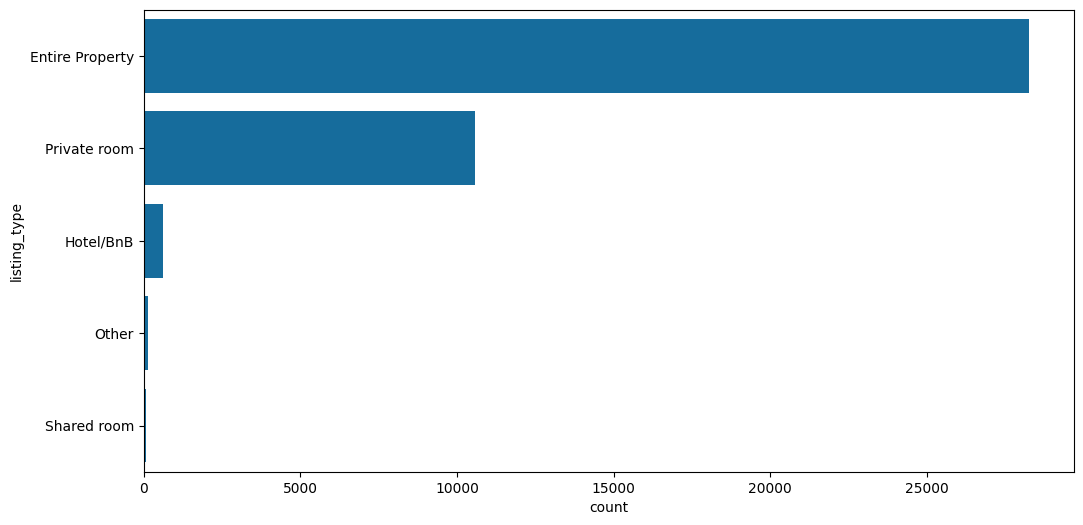

In [321]:
listing_order = df_clean['listing_type'].value_counts().index
plt.figure(figsize=(12,6))
sns.countplot(data=df_clean, y='listing_type', order=listing_order)


The above visual shows what would be expected with an AirBnB listing dataset. The vast majority of listings are either entire properties or private rooms.

#### **2.2 Multivariate Analysis**
* Correlation matrix - Investigating relationships between metrics to find metrics correlated with price
* Creation of price per person metric
* Investigating how price per person changes with property type and location

<function matplotlib.pyplot.show(close=None, block=None)>

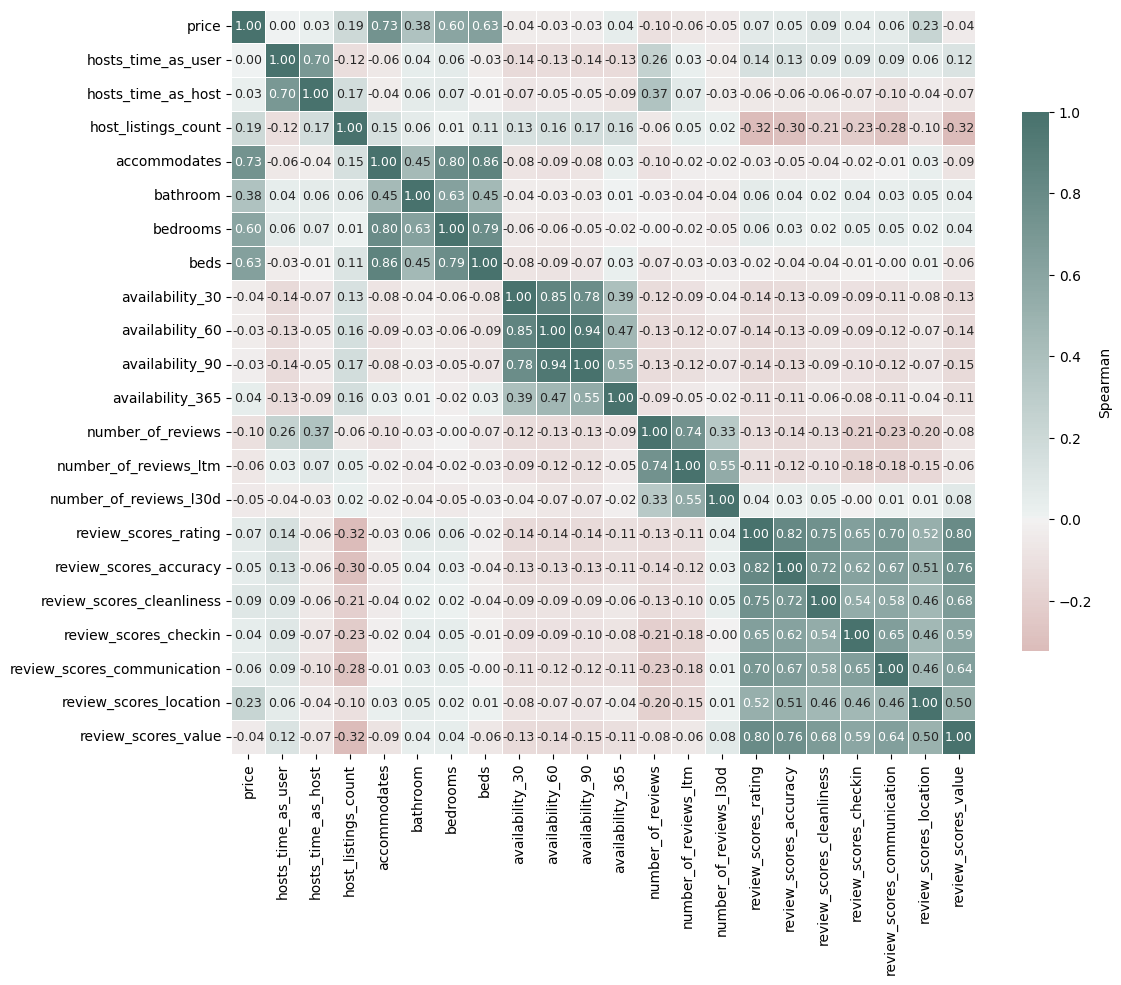

In [322]:
num_cols = [
            'price',
             'hosts_time_as_user',
             'hosts_time_as_host',
             'host_listings_count',
             'accommodates',
             'bathroom',
             'bedrooms',
             'beds',
             'availability_30',
             'availability_60',
             'availability_90',
             'availability_365',
             'number_of_reviews',
             'number_of_reviews_ltm',
             'number_of_reviews_l30d',
             'review_scores_rating',
             'review_scores_accuracy',
             'review_scores_cleanliness',
             'review_scores_checkin',
             'review_scores_communication',
             'review_scores_location',
             'review_scores_value']

corr = df_clean[num_cols].corr(method='spearman') # spearman used as it works with all datatypes (ordinal, ranked, continuous and doesn't assume normality)
cmap = sns.diverging_palette(15, 180, s=55, l=45, as_cmap=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
      corr,
      annot=True,
      cmap=cmap,
      fmt=".2f",
      center=0,
      linewidths=0.5,
      linecolor='white',
      square=True,
      annot_kws={'size': 9},
      cbar_kws={"label": "Spearman", "shrink": 0.7}
      )
plt.show

The correlation matrix returns some findings which would be expected and can be used going forward in the analysis

* Price is strongly correlated with size of property metrics. Accomodates is the strongest corrrelation and this is the metric without nulls so will be used going forward as the size metric

* The only other interesting correlation, absolute correlation greater than > 0.2, is the review score on location at 0.23. Although it is relatively weak, all other review scores correlate at less than absolute 0.1. This suggesting that in London, the location of the property is the only review metric correlated with more expensive listings


* Interestingly, a host having a greater number of listings correlates with weaker review scores across the board for everything but location. Suggesting that professional airbnb lettings companies are correlated with lower reviews from customers

These findings suggest that a metric which normalises for the people that can stay in the listing should be calculated

In [323]:
df_clean['price_per_person'] = df_clean['price'] / df_clean['accommodates']
df_clean[['listing_type', 'neighbourhood', 'accommodates', 'price', 'price_per_person']].sort_values('price_per_person', ascending=False)

,listing_type,neighbourhood,accommodates,price,price_per_person
57175,Entire Property,Westminster,2,10053.50,5026.750000
25762,Entire Property,Tower Hamlets,2,10000.00,5000.000000
25782,Entire Property,Tower Hamlets,2,9000.00,4500.000000
47478,Entire Property,Bromley,4,10000.00,2500.000000
67186,Entire Property,Ealing,1,1943.33,1943.330000
...,...,...,...,...,...
561,Entire Property,Greenwich,6,34.63,5.771667
86060,Entire Property,Croydon,4,22.86,5.715000
10008,Entire Property,Croydon,8,44.55,5.568750
42494,Private room,Southwark,2,10.49,5.245000


The hist plot below still shows that we are heavily skewed to the right with most values still grouped towards zero with some extreme outliers up to 5000 which we have already investigated to be valid listings. The distribution suggests to use medians and IQR's which are more robuts or uneffected by distribution

<Axes: xlabel='price_per_person', ylabel='Count'>

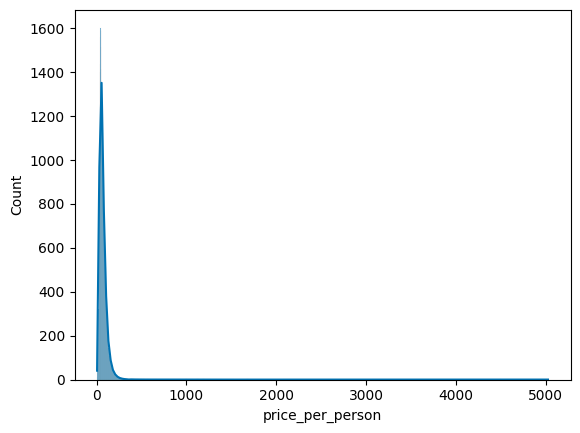

In [324]:
sns.histplot(df_clean, x='price_per_person', kde=True)

<function matplotlib.pyplot.show(close=None, block=None)>

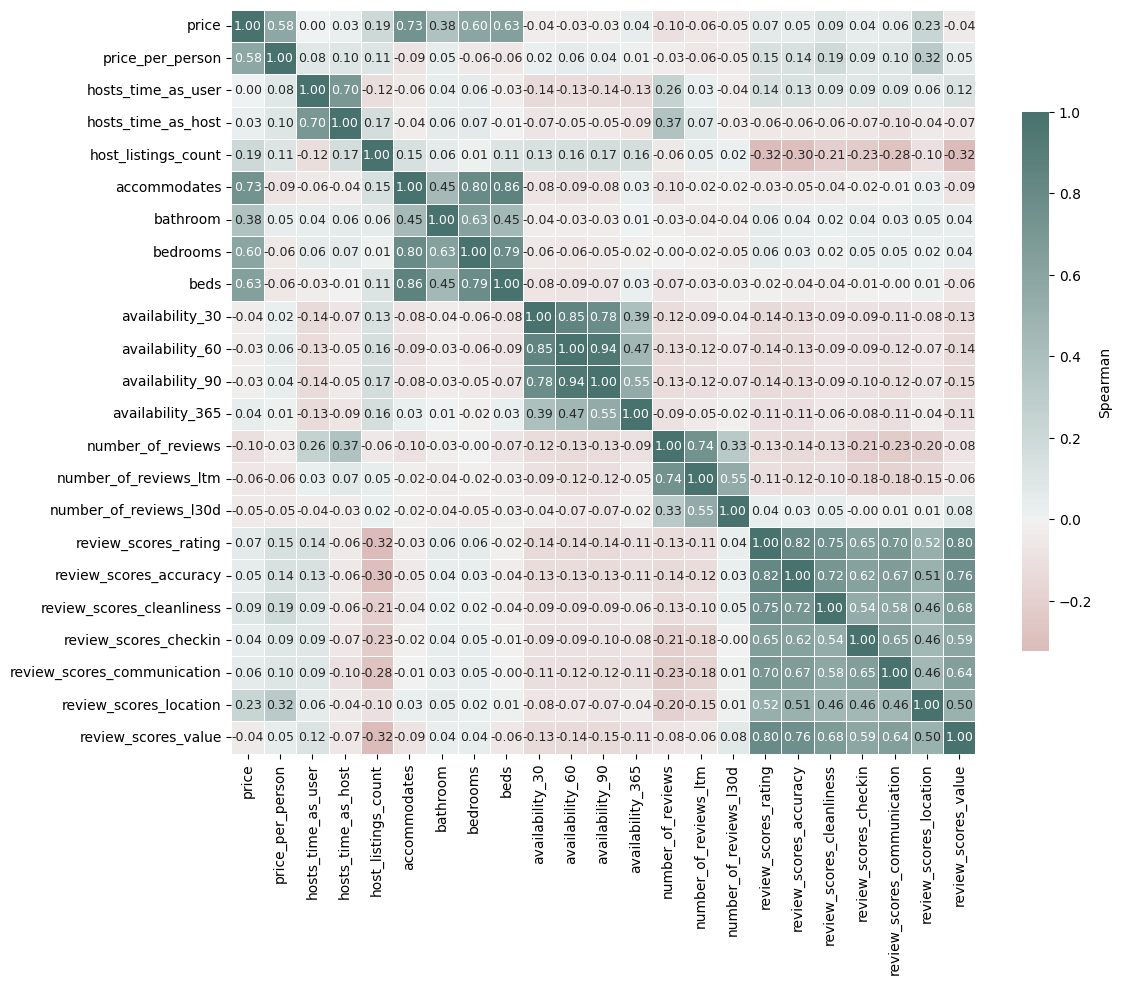

In [325]:
num_cols = [
            'price',
            'price_per_person',
             'hosts_time_as_user',
             'hosts_time_as_host',
             'host_listings_count',
             'accommodates',
             'bathroom',
             'bedrooms',
             'beds',
             'availability_30',
             'availability_60',
             'availability_90',
             'availability_365',
             'number_of_reviews',
             'number_of_reviews_ltm',
             'number_of_reviews_l30d',
             'review_scores_rating',
             'review_scores_accuracy',
             'review_scores_cleanliness',
             'review_scores_checkin',
             'review_scores_communication',
             'review_scores_location',
             'review_scores_value']

corr = df_clean[num_cols].corr(method='spearman') # spearman used as it works with all datatypes (ordinal, ranked, continuous and doesn't assume normality)
cmap = sns.diverging_palette(15, 180, s=55, l=45, as_cmap=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
      corr,
      annot=True,
      cmap=cmap,
      fmt=".2f",
      center=0,
      linewidths=0.5,
      linecolor='white',
      square=True,
      annot_kws={'size': 9},
      cbar_kws={"label": "Spearman", "shrink": 0.7}
      )
plt.show

This second correlation matrix visual shows that once we normalise for the price per person per night, the only correlation with strength seen is in the review_scores_location which strengthens to 0.32

### Impact of Property Listing Type
One metric that hasn't yet been analysed is the listing type to undrstand if we see variances between these groupings of property types.

The below table shows that the median (used as price per person is skewed heavily to the right meaning mean overestimates the true central tendancy) differs between the listings types with private room and shared room coming in much lower than the other categories. This is an expected finding but shows that the listing type should be included within any buckets / groups created.

In [326]:
df_clean.groupby('listing_type', observed=True)['price_per_person'].agg([ 'count', 'mean', 'median', 'skew'])

,count,mean,median,skew
listing_type,,,,
Entire Property,28272,75.189266,64.167500,36.847642
Hotel/BnB,604,78.864230,69.066667,1.721065
Other,126,73.453286,63.750000,1.326329
Private room,10589,52.756758,46.000000,7.662565
Shared room,85,35.635157,33.000000,1.721227


Grouping listings by the found drivers of the price metric, location and property listing type


In [327]:
df_drivers = df_clean.groupby(['neighbourhood', 'listing_type']).agg(
    count=('price_per_person', 'count'),
    median=('price_per_person', 'median'),
    mean=('price_per_person', 'mean'),
    std=('price_per_person', 'std'),
    cv=('price_per_person', lambda s: s.std() / s.mean()),
    q1=('price_per_person', lambda s: s.quantile(0.25)),
    q3=('price_per_person', lambda s: s.quantile(0.75)),
    min=('price_per_person', 'min'),
    max=('price_per_person', 'max')
)
df_drivers

count     median        mean        std  \
neighbourhood        listing_type                                               
Barking and Dagenham Entire Property    139  36.750000   40.612693  17.338713   
                     Hotel/BnB            1  33.000000   33.000000        NaN   
                     Other                1  14.400000   14.400000        NaN   
                     Private room       113  31.250000   38.809558  25.622081   
Barnet               Entire Property    725  46.666667   50.959665  25.098738   
...                                     ...        ...         ...        ...   
Westminster          Entire Property   4737  87.500000  100.633376  91.029579   
                     Hotel/BnB          193  81.000000   87.813938  42.951085   
                     Other               16  54.666667   62.315458  45.411421   
                     Private room       618  66.500000   76.305909  40.805897   
                     Shared room          7  30.666667   26.642857  11.034638   

                                            cv         q1          q3  \
neighbourhood        listing_type                                       
Barking and Dagenham Entire Property  0.426928  30.750000   47.175000   
                     Hotel/BnB             NaN  33.000000   33.000000   
                     Other                 NaN  14.400000   14.400000   
                     Private room     0.660200  25.000000   42.500000   
Barnet               Entire Property  0.492522  37.250000   59.333333   
...                                        ...        ...         ...   
Westminster          Entire Property  0.904566  63.166667  120.976667   
                     Hotel/BnB        0.489115  55.000000  105.825000   
                     Other            0.728734  33.187500   73.562500   
                     Private room     0.534767  49.500000   92.000000   
                     Shared room      0.414169  17.500000   33.666667   

                                            min      max  
neighbourhood        listing_type                         
Barking and Dagenham Entire Property   6.074444   136.50  
                     Hotel/BnB        33.000000    33.00  
                     Other            14.400000    14.40  
                     Private room     13.333333   211.00  
Barnet               Entire Property   8.166667   424.00  
...                                         ...      ...  
Westminster          Entire Property   9.756667  5026.75  
                     Hotel/BnB        31.666667   349.00  
                     Other            10.538333   176.50  
                     Private room     16.666667   382.00  
                     Shared room      12.000000    41.50  

[145 rows x 9 columns]

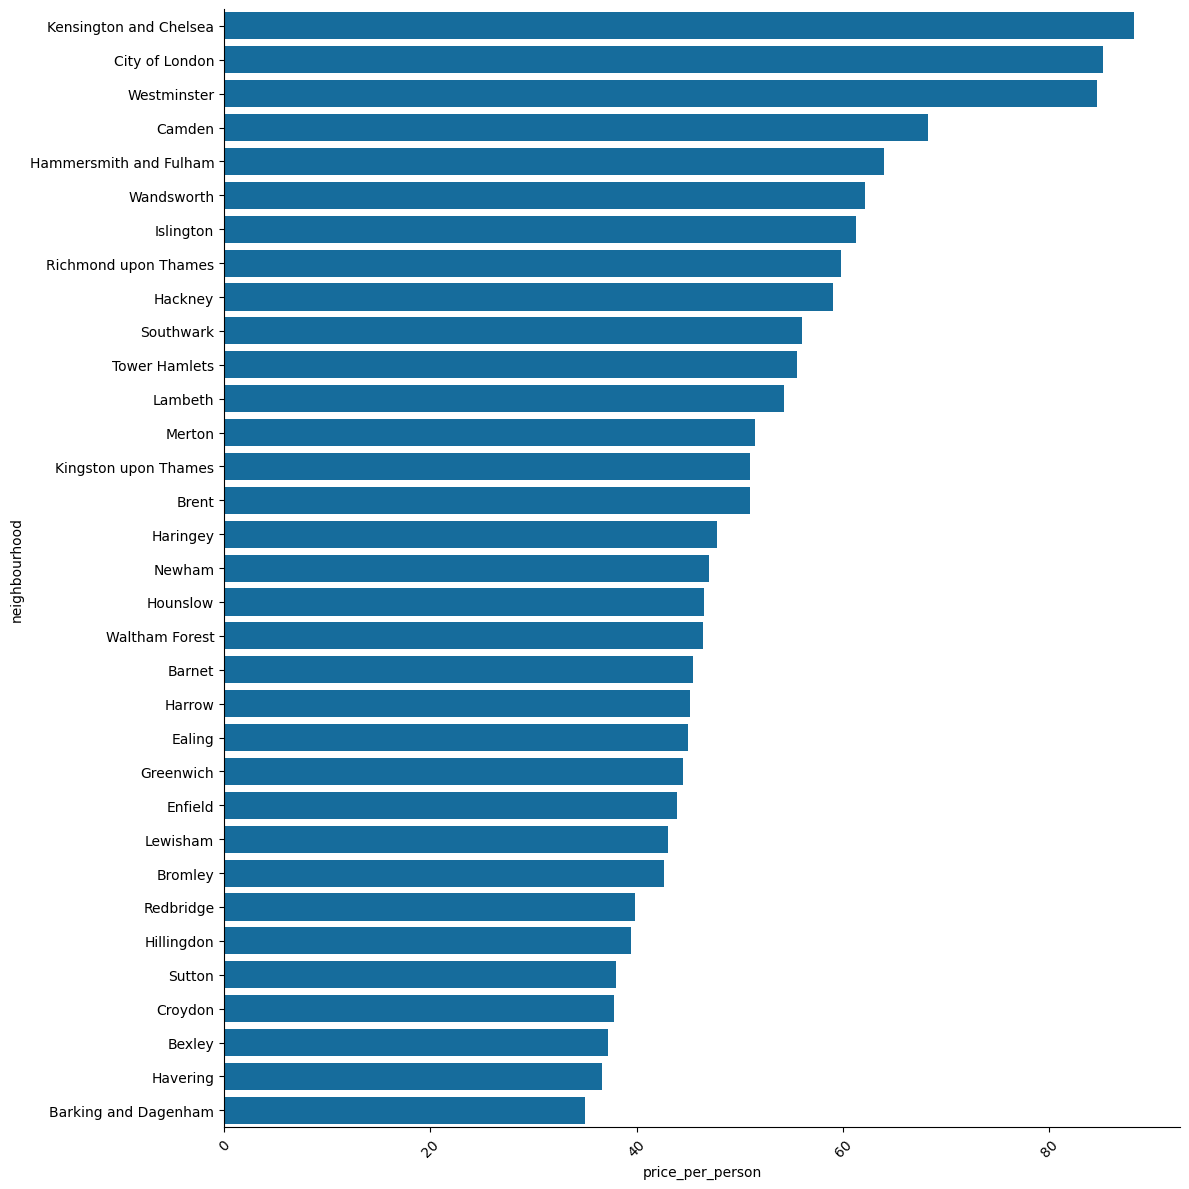

In [328]:
plt.figure(figsize=(12,12))
df_median = df_clean.groupby('neighbourhood').agg({'price_per_person': 'median'}).sort_values('price_per_person', ascending=False)


ax = sns.barplot(data=df_median, y='neighbourhood', x='price_per_person')
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

### Median Price Per Person by location and Property group
This visual shows the varying range of price per persons for listings within each location by property type and show that both factors result in different prices.

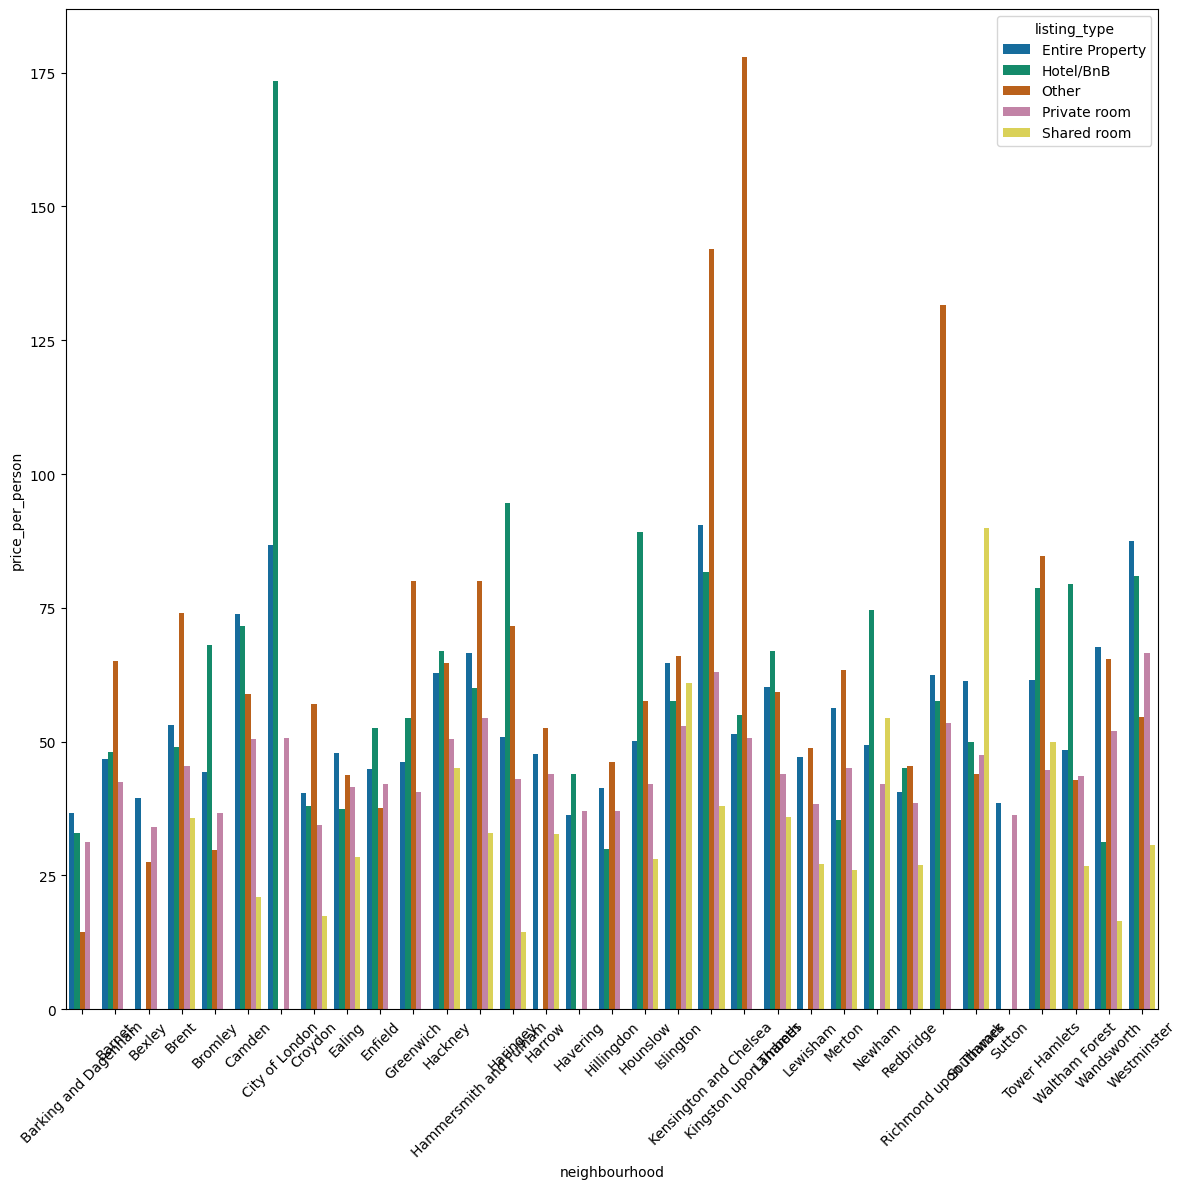

In [329]:
plt.figure(figsize=(12,12))
df_median = df_clean.groupby(['neighbourhood', 'listing_type']).agg({'price_per_person': 'median'})


ax = sns.barplot(data=df_median, x='neighbourhood', y='price_per_person', hue='listing_type')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [330]:
df_drivers


count     median        mean        std  \
neighbourhood        listing_type                                               
Barking and Dagenham Entire Property    139  36.750000   40.612693  17.338713   
                     Hotel/BnB            1  33.000000   33.000000        NaN   
                     Other                1  14.400000   14.400000        NaN   
                     Private room       113  31.250000   38.809558  25.622081   
Barnet               Entire Property    725  46.666667   50.959665  25.098738   
...                                     ...        ...         ...        ...   
Westminster          Entire Property   4737  87.500000  100.633376  91.029579   
                     Hotel/BnB          193  81.000000   87.813938  42.951085   
                     Other               16  54.666667   62.315458  45.411421   
                     Private room       618  66.500000   76.305909  40.805897   
                     Shared room          7  30.666667   26.642857  11.034638   

                                            cv         q1          q3  \
neighbourhood        listing_type                                       
Barking and Dagenham Entire Property  0.426928  30.750000   47.175000   
                     Hotel/BnB             NaN  33.000000   33.000000   
                     Other                 NaN  14.400000   14.400000   
                     Private room     0.660200  25.000000   42.500000   
Barnet               Entire Property  0.492522  37.250000   59.333333   
...                                        ...        ...         ...   
Westminster          Entire Property  0.904566  63.166667  120.976667   
                     Hotel/BnB        0.489115  55.000000  105.825000   
                     Other            0.728734  33.187500   73.562500   
                     Private room     0.534767  49.500000   92.000000   
                     Shared room      0.414169  17.500000   33.666667   

                                            min      max  
neighbourhood        listing_type                         
Barking and Dagenham Entire Property   6.074444   136.50  
                     Hotel/BnB        33.000000    33.00  
                     Other            14.400000    14.40  
                     Private room     13.333333   211.00  
Barnet               Entire Property   8.166667   424.00  
...                                         ...      ...  
Westminster          Entire Property   9.756667  5026.75  
                     Hotel/BnB        31.666667   349.00  
                     Other            10.538333   176.50  
                     Private room     16.666667   382.00  
                     Shared room      12.000000    41.50  

[145 rows x 9 columns]

### Property ratio's

Inclusion of the 10th and 90th percentile here to create a 90/10 percentile ratio to show dispersion within the groupings.

This ratio is inspired by analysis of [economic inequality](https://ourworldindata.org/economic-inequality) and was used to show how much greater the top earners are than the lower earners. This will be applied to show the spread of price per person within the driver groups to show that there is still further analysis into drivers required.


This analysis only includes buckets / groupings whereby there is at least 30 properties so that small buckets don't skew the values with extreme values.

Both the interquartile ratio and the p90/10 ratio show that the spread in price per person is still great within the groups created here.

Fixing on the neighbourhood (location) and the number of people accomodated for, the most expensive propertis are 2.84 times more expensive than the cheapest 10% of properties.

Using the interquartile ratio, the spread between the 75th percentile and 25th percintile is still 1.73 times higher

In [331]:
df_drivers = df_clean.groupby(['neighbourhood', 'listing_type']).agg(
    count=('price_per_person', 'count'),
    median=('price_per_person', 'median'),
    mean=('price_per_person', 'mean'),
    std=('price_per_person', 'std'),
    cv=('price_per_person', lambda s: s.std() / s.mean()),
    p10=('price_per_person', lambda s: s.quantile(0.10)),
    p90=('price_per_person', lambda s: s.quantile(0.90)),
    q1=('price_per_person', lambda s: s.quantile(0.25)),
    q3=('price_per_person', lambda s: s.quantile(0.75)),
    min=('price_per_person', 'min'),
    max=('price_per_person', 'max')
)
df_drivers
df_drivers['iq_ratio'] = df_drivers['q3'] / df_drivers['q1']
df_drivers['p90/p10_ratio'] = df_drivers['p90'] / df_drivers['p10']
df_drivers

count     median        mean        std  \
neighbourhood        listing_type                                               
Barking and Dagenham Entire Property    139  36.750000   40.612693  17.338713   
                     Hotel/BnB            1  33.000000   33.000000        NaN   
                     Other                1  14.400000   14.400000        NaN   
                     Private room       113  31.250000   38.809558  25.622081   
Barnet               Entire Property    725  46.666667   50.959665  25.098738   
...                                     ...        ...         ...        ...   
Westminster          Entire Property   4737  87.500000  100.633376  91.029579   
                     Hotel/BnB          193  81.000000   87.813938  42.951085   
                     Other               16  54.666667   62.315458  45.411421   
                     Private room       618  66.500000   76.305909  40.805897   
                     Shared room          7  30.666667   26.642857  11.034638   

                                            cv        p10       p90  \
neighbourhood        listing_type                                     
Barking and Dagenham Entire Property  0.426928  24.497314   59.8835   
                     Hotel/BnB             NaN  33.000000   33.0000   
                     Other                 NaN  14.400000   14.4000   
                     Private room     0.660200  20.000000   62.4000   
Barnet               Entire Property  0.492522  29.406667   74.5000   
...                                        ...        ...       ...   
Westminster          Entire Property  0.904566  47.933929  163.8500   
                     Hotel/BnB        0.489115  45.000000  139.2750   
                     Other            0.728734  20.025000  117.4375   
                     Private room     0.534767  38.000000  123.3810   
                     Shared room      0.414169  13.800000   37.2000   

                                             q1          q3        min  \
neighbourhood        listing_type                                        
Barking and Dagenham Entire Property  30.750000   47.175000   6.074444   
                     Hotel/BnB        33.000000   33.000000  33.000000   
                     Other            14.400000   14.400000  14.400000   
                     Private room     25.000000   42.500000  13.333333   
Barnet               Entire Property  37.250000   59.333333   8.166667   
...                                         ...         ...        ...   
Westminster          Entire Property  63.166667  120.976667   9.756667   
                     Hotel/BnB        55.000000  105.825000  31.666667   
                     Other            33.187500   73.562500  10.538333   
                     Private room     49.500000   92.000000  16.666667   
                     Shared room      17.500000   33.666667  12.000000   

                                          max  iq_ratio  p90/p10_ratio  
neighbourhood        listing_type                                       
Barking and Dagenham Entire Property   136.50  1.534146       2.444492  
                     Hotel/BnB          33.00  1.000000       1.000000  
                     Other              14.40  1.000000       1.000000  
                     Private room      211.00  1.700000       3.120000  
Barnet               Entire Property   424.00  1.592841       2.533439  
...                                       ...       ...            ...  
Westminster          Entire Property  5026.75  1.915198       3.418247  
                     Hotel/BnB         349.00  1.924091       3.095000  
                     Other             176.50  2.216573       5.864544  
                     Private room      382.00  1.858586       3.246868  
                     Shared room        41.50  1.923810       2.695652  

[145 rows x 13 columns]

In [332]:
df_drivers_filter = df_drivers[df_drivers['count'] > 30].copy()
df_drivers_filter['iq_ratio'].agg(['mean', 'median', 'var'])

,iq_ratio
mean,1.731032
median,1.738235
var,0.011897


In [333]:
df_drivers_filter = df_drivers[df_drivers['count'] > 30].copy()
df_drivers_filter['p90/p10_ratio'].agg(['mean', 'median', 'var', 'skew'])

,p90/p10_ratio
mean,2.837710
median,2.843926
var,0.078046
skew,-0.010616


<Axes: xlabel='iq_ratio', ylabel='Count'>

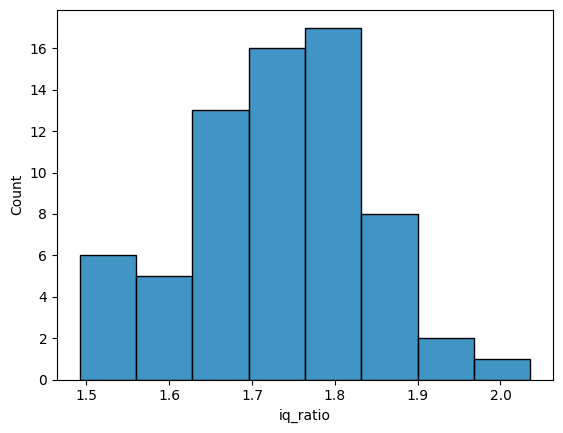

In [334]:
sns.histplot(df_drivers_filter, x='iq_ratio')

<Axes: xlabel='p90/p10_ratio', ylabel='Count'>

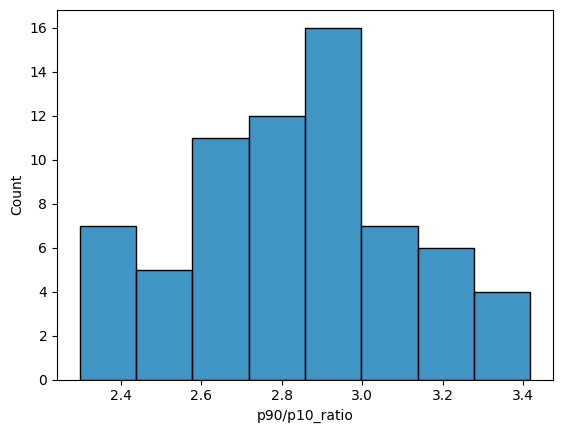

In [335]:
sns.histplot(df_drivers_filter, x='p90/p10_ratio')

In [336]:
print(f"median P90/P10: {df_drivers_filter['p90/p10_ratio'].median():.2f}")
print(f"median P75/P25: {df_drivers_filter['iq_ratio'].median():.2f}")
print(f"{len(df_drivers_filter)} buckets, {df_drivers_filter['count'].sum()/len(df_clean):.0%} coverage")

median P90/P10: 2.84
median P75/P25: 1.74
68 buckets, 99% coverage


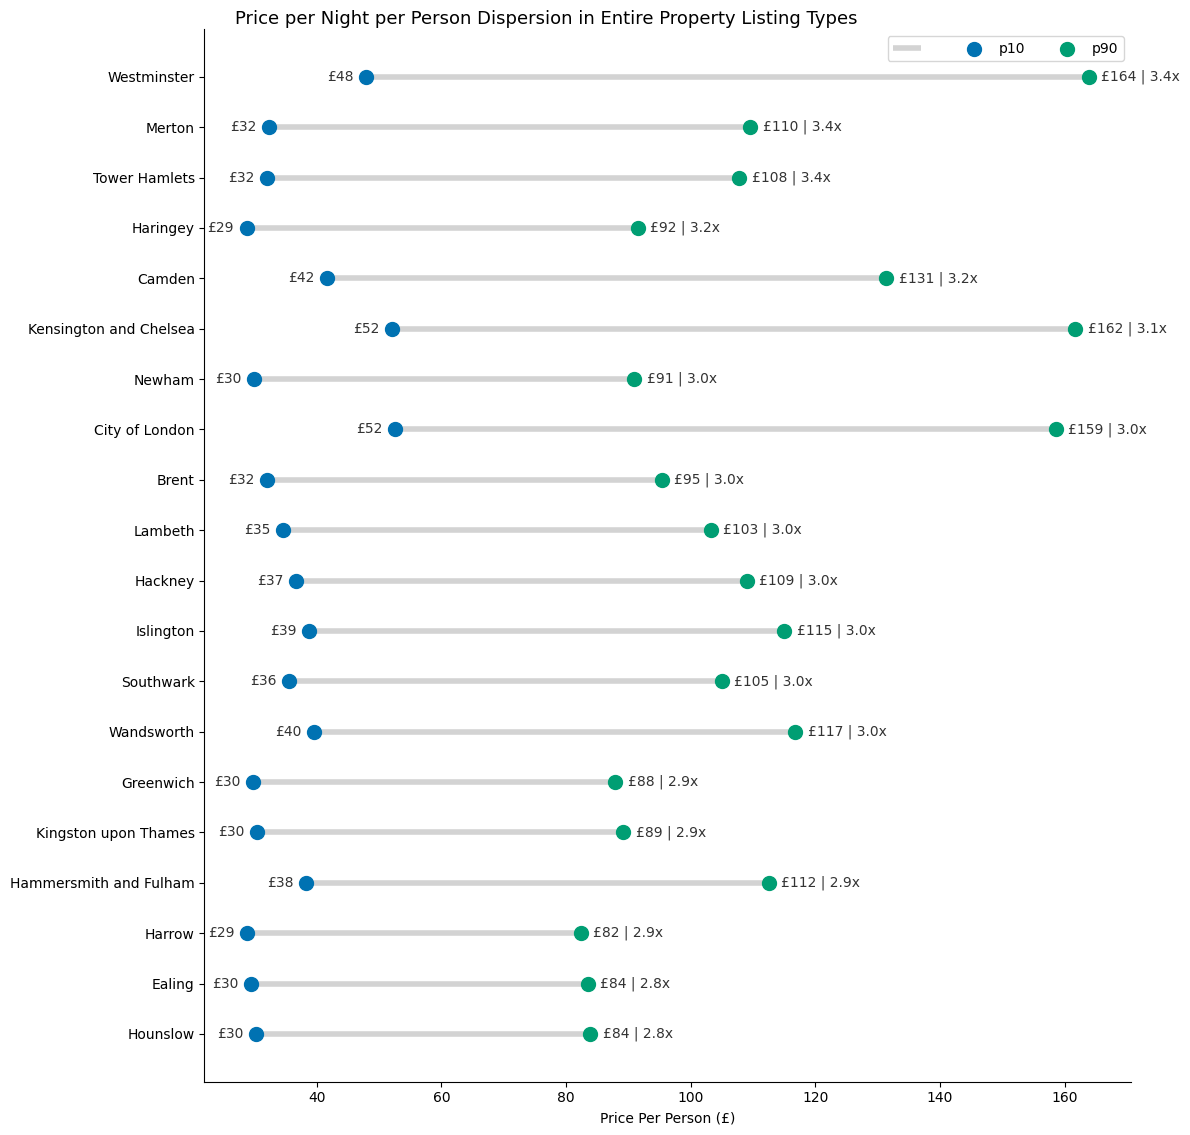

In [337]:
df_entire_property = df_drivers_filter[df_drivers_filter.index.get_level_values(1) == 'Entire Property'].copy()
df_entire_property = df_entire_property.nlargest(20, 'p90/p10_ratio').sort_values('p90/p10_ratio', ascending=False)

neighbourhood = df_entire_property.index.get_level_values(0)
p10 = df_entire_property['p10']
p90 = df_entire_property['p90']
ratio = df_entire_property['p90/p10_ratio']
fig, ax = plt.subplots(1,1, figsize=(12,12))
ax.invert_yaxis()
ax.hlines(neighbourhood, p10, p90, color='#D3D3D3', linewidth=4)
ax.scatter(x=p10, y=neighbourhood, s=100, label='p10', zorder=2)
ax.scatter(x=p90, y=neighbourhood, s=100, label='p90', zorder=2)

for n, lo, hi, r in zip(neighbourhood, p10, p90, ratio):
    ax.text(lo - 2, n, f'£{lo:.0f}', va='center', ha='right', color='#333333')
    ax.text(hi + 2, n, f'£{hi:.0f} | {r:.1f}x' , va='center', ha='left', color='#333333')

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Price Per Person (£)')
ax.legend(['','p10', 'p90'], ncol = 3)
ax.text(x=0.2, y=0.93, s="Price per Night per Person Dispersion in Entire Property Listing Types", transform=fig.transFigure, fontsize=13)
plt.tight_layout()
plt.show()

### **2.3 Outliers Detection**
Outlier detection using the interquartile range due to the price per person metric being heavily right skewed

In [338]:
df_grouped = df_clean.copy()
group = df_clean.groupby(['neighbourhood', 'listing_type'])['price_per_person']

# for every row in the dataset it calculates the 10th and 90th decile, like a window function in sql. It does not collapse / aggregate up
df_grouped['q1'] = group.transform(lambda s: s.quantile(0.25))
df_grouped['q3'] = group.transform(lambda s: s.quantile(0.75))
df_grouped['n']   = group.transform('size')
df_grouped['iqr'] = df_grouped['q3'] - df_grouped['q1']
df_grouped['lower_bound'] = df_grouped['q1'] - (1.5 * df_grouped['iqr'])
df_grouped['upper_bound'] = df_grouped['q3'] + (1.5 * df_grouped['iqr'])

df_grouped['price_outlier_flag'] = np.select(
    [df_grouped['n'] < 30, df_grouped['price_per_person'] < df_grouped['lower_bound'], df_grouped['price_per_person'] > df_grouped['upper_bound']],
    ['insufficient_properties', 'below_market','above_market'], default='normally_priced')
df_grouped[['id', 'neighbourhood', 'property_type', 'accommodates', 'price_per_person', 'price_outlier_flag', 'q1', 'q3', 'iqr', 'lower_bound', 'upper_bound']].head()


,id,neighbourhood,property_type,accommodates,price_per_person,price_outlier_flag,q1,q3,iqr,lower_bound,upper_bound
0,11551,Lambeth,Entire rental unit,5,46.900000,normally_priced,44.583333,81.000000,36.416667,-10.041667,135.625000
1,13913,Islington,Private room in rental unit,1,127.000000,above_market,41.000000,71.000000,30.000000,-4.000000,116.000000
2,15400,Kensington and Chelsea,Entire rental unit,2,68.750000,normally_priced,68.250000,120.416667,52.166667,-10.000000,198.666667
3,17402,Westminster,Entire rental unit,6,101.111667,normally_priced,63.166667,120.976667,57.810000,-23.548333,207.691667
4,513198,Lambeth,Private room in rental unit,1,68.300000,normally_priced,35.500000,59.687500,24.187500,-0.781250,95.968750


In [339]:
df_grouped['price_outlier_flag'].value_counts()

,count
price_outlier_flag,
normally_priced,37693
above_market,1509
insufficient_properties,472
below_market,2


The above code adds an outlier flag for properties using the iqr of their respective location and accomodation grouping.

Value counts for the number of properties flagged can be seen. These flags can then be used to notify hosts that their properties are priced above or below their relative market and a repricing could be considered if bookings are very strong or qually very weak.

This shows that the iqr does not detect any under priced flights due to the distribution of the data with a wide spread and a central tendency is close to the floor of zero. Therefore a percentile ranking method is going to be more suitable for this. Properties in the bottom 10% and top 10% will now be flagged.

In [340]:
df_grouped_pct = df_clean.copy()

group_pct = df_clean.groupby(['neighbourhood', 'listing_type'])['price_per_person']

# for every row in the dataset it calculates the 10th and 90th decile, like a window function in sql. It does not collapse / aggregate up
df_grouped_pct['p10'] = group_pct.transform(lambda s: s.quantile(0.1))
df_grouped_pct['p90'] = group_pct.transform(lambda s: s.quantile(0.9))
df_grouped_pct['n']   = group_pct.transform('size')
df_grouped_pct['pct_in_bucket'] = group_pct.rank(pct=True)


df_grouped_pct['price_outlier_flag'] = np.select(
    [df_grouped_pct['n'] < 30, df_grouped_pct['pct_in_bucket'] <= 0.1, df_grouped_pct['pct_in_bucket'] >= 0.9],
    ['insufficient_properties', 'below_market','above_market'], default='normally_priced')
df_grouped_pct[['id', 'neighbourhood', 'property_type', 'accommodates', 'price_per_person', 'price_outlier_flag', 'p10', 'p90', 'pct_in_bucket']].head(20)


,id,neighbourhood,property_type,accommodates,price_per_person,price_outlier_flag,p10,p90,pct_in_bucket
0,11551,Lambeth,Entire rental unit,5,46.900000,normally_priced,34.618444,103.2000,0.280536
1,13913,Islington,Private room in rental unit,1,127.000000,above_market,32.550000,95.0000,0.986755
2,15400,Kensington and Chelsea,Entire rental unit,2,68.750000,normally_priced,52.125000,161.6700,0.258892
3,17402,Westminster,Entire rental unit,6,101.111667,normally_priced,47.933929,163.8500,0.622968
4,513198,Lambeth,Private room in rental unit,1,68.300000,normally_priced,27.500000,77.0000,0.838440
9,517283,Redbridge,Entire home,7,38.332857,normally_priced,24.383000,65.1300,0.442211
13,354003,Kensington and Chelsea,Entire rental unit,4,84.625000,normally_priced,52.125000,161.6700,0.444028
14,356073,Newham,Private room in townhouse,1,37.400000,normally_priced,25.000000,71.8500,0.381818
18,362026,Haringey,Private room in home,2,22.500000,below_market,25.000000,74.9300,0.073034
20,365933,Lambeth,Entire condo,4,40.750000,normally_priced,34.618444,103.2000,0.187549


# **3. Summary**
This data shows the potential for flagging property pricing outlier vs the factors we can determine drive pricing. However, there is still a high variance within the price per person within these identified groups. This variance could be caused by differences in amenities, the quality of images and details provided on the listing. However, this has not been tested within this analyses and future work should look to dive deeper into the causes of this price variation.

This work could be used as a pre-cursor to a full pricing elasticity model via the integration of bookings data as well as search and conversions data to create a full model / product to optimise the revenue model